
================ 🤖 ADVANCED AI STOCK PRICE PREDICTOR =================

✨ Features:
  • Real-time data fetching from Yahoo Finance
  • Multiple AI/ML models (LSTM, Random Forest, XGBoost)
  • Advanced technical indicators
  • Future price predictions
  • Comprehensive visualizations
  • Works for ANY stock ticker!

----------------------------------------------------------------------

📈 Enter stock ticker symbol (e.g., AAPL, TSLA, GOOGL): AAPL

📅 Data period options:
  1. Last 1 year
  2. Last 2 years
  3. Last 3 years (Recommended)
  4. Last 5 years
  5. Custom

Select period (1-5): 2

📊 Fetching REAL-TIME data for AAPL...

✓ Data fetched successfully!
  Company: Apple Inc.
  Sector: Technology
  Industry: Consumer Electronics
  Date Range: 2023-10-17 to 2025-10-16
  Total Trading Days: 502
  Latest Price: $247.45

🔧 Creating advanced technical indicators...
✓ Created 51 features. Dataset: 303 rows

----------------------------------------------------------------------

🎯 Training C


  LSTM Metrics:
    • RMSE: $8.97
    • MAE:  $7.56
    • R²:   0.3472
    • MAPE: 3.13%

[2/3] Training Random Forest Model...

  Random Forest Metrics:
    • RMSE: $6.41
    • MAE:  $5.36
    • R²:   0.8324
    • MAPE: 2.25%

[3/3] Training XGBoost Model...

  XGBoost Metrics:
    • RMSE: $6.10
    • MAE:  $4.96
    • R²:   0.8482
    • MAPE: 2.12%

  Ensemble Metrics:
    • RMSE: $12.03
    • MAE:  $10.19
    • R²:   -0.1736
    • MAPE: 4.22%

✅ ALL MODELS TRAINED SUCCESSFULLY!

📄 STOCK PREDICTION REPORT - AAPL

📊 STOCK INFORMATION:
  • Ticker Symbol: AAPL
  • Analysis Period: 2024-08-02 to 2025-10-16
  • Current Price: $247.45
  • Total Return: +13.20%
  • 52-Week High: $258.10
  • 52-Week Low: $172.00

🤖 MODEL PERFORMANCE:

  LSTM:
    RMSE: $8.97 | MAE: $7.56 | R²: 0.3472 | MAPE: 3.13%

  RF:
    RMSE: $6.41 | MAE: $5.36 | R²: 0.8324 | MAPE: 2.25%

  XGB:
    RMSE: $6.10 | MAE: $4.96 | R²: 0.8482 | MAPE: 2.12%

  ENSEMBLE:
    RMSE: $12.03 | MAE: $10.19 | R²: -0.1736 | MAPE: 4.2

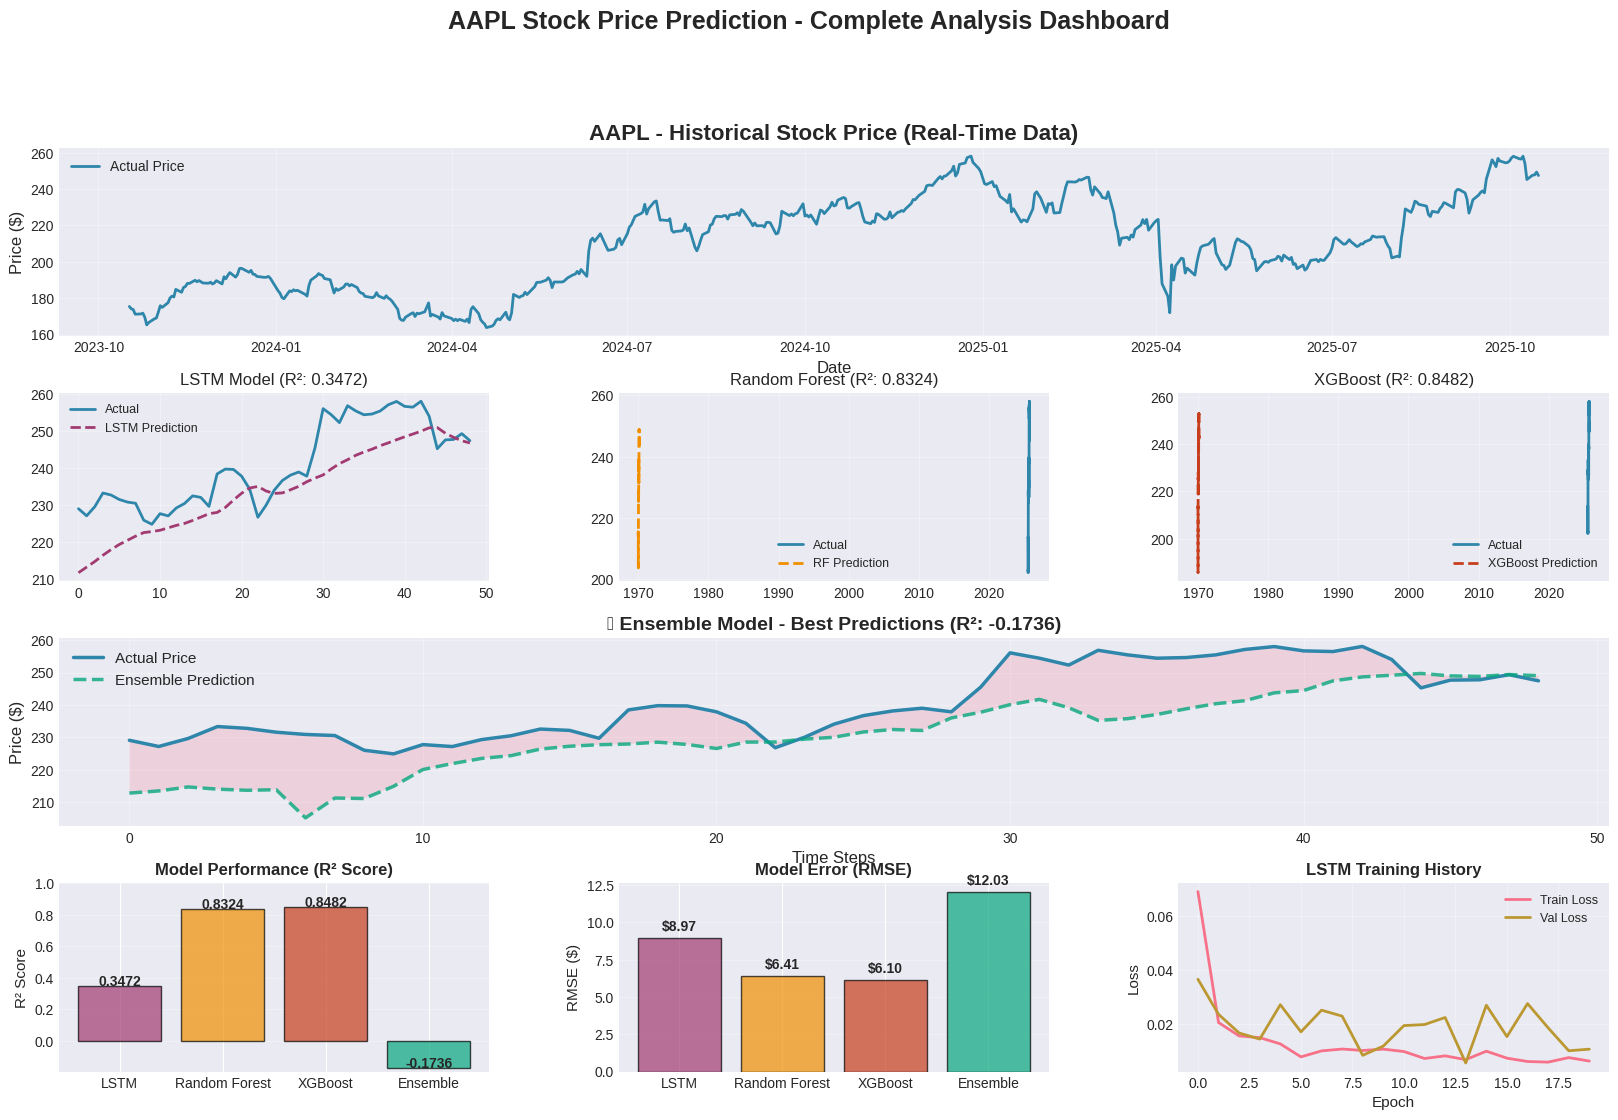

✓ Feature importance saved as 'AAPL_feature_importance.png'


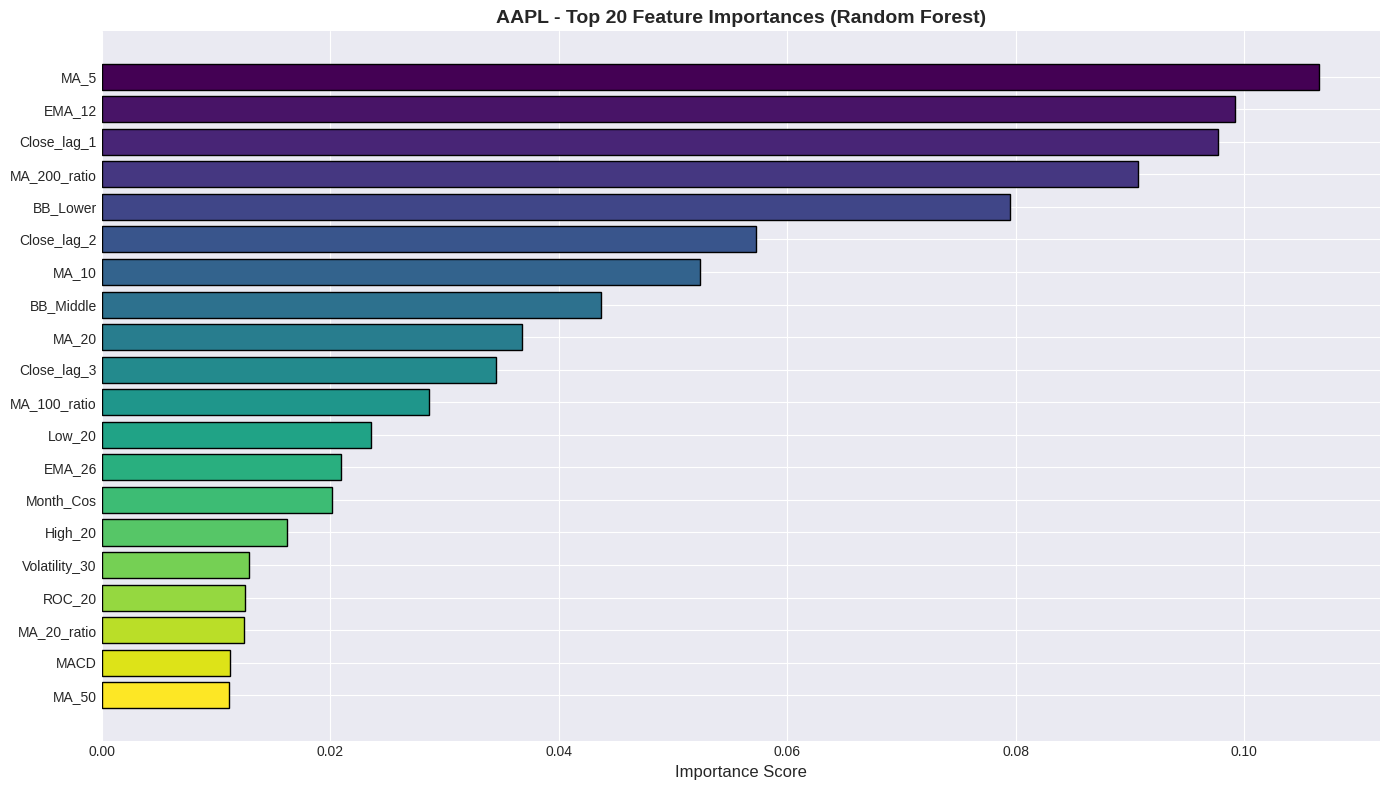


----------------------------------------------------------------------

🔮 Enter number of days to predict (default 30): 30

🔮 Predicting next 30 days...
✓ Future prediction saved as 'AAPL_future_prediction.png'


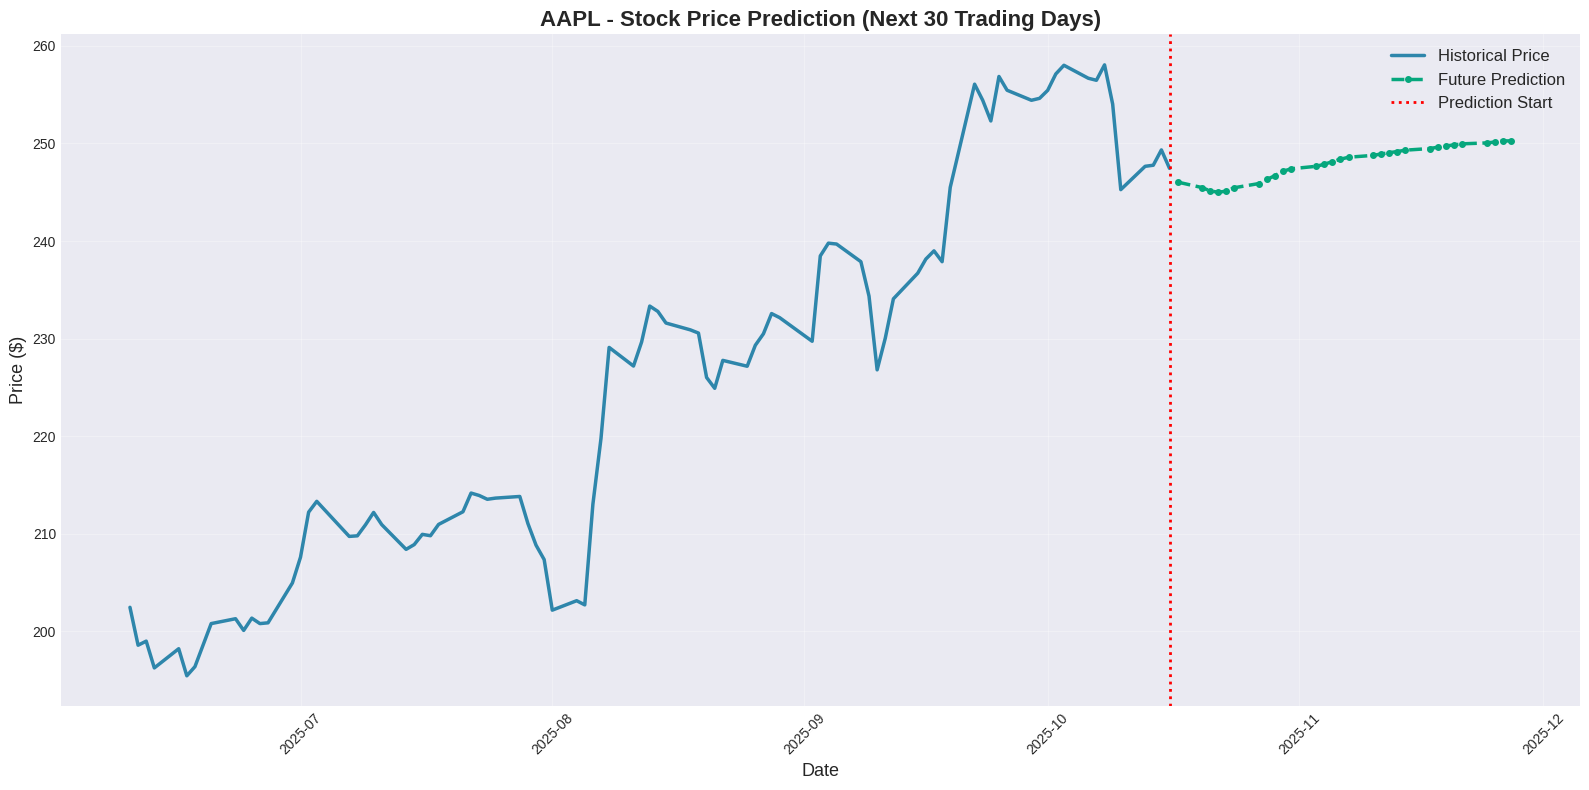


📊 Future Price Predictions:
                     Date  Predicted_Price
2025-10-17 00:00:00-04:00       246.043410
2025-10-20 00:00:00-04:00       245.481106
2025-10-21 00:00:00-04:00       245.140787
2025-10-22 00:00:00-04:00       244.998598
2025-10-23 00:00:00-04:00       245.120401
2025-10-24 00:00:00-04:00       245.466874
2025-10-27 00:00:00-04:00       245.889961
2025-10-28 00:00:00-04:00       246.307576
2025-10-29 00:00:00-04:00       246.717509
2025-10-30 00:00:00-04:00       247.162172
2025-10-31 00:00:00-04:00       247.407103
2025-11-03 00:00:00-05:00       247.658891
2025-11-04 00:00:00-05:00       247.866659
2025-11-05 00:00:00-05:00       248.134711
2025-11-06 00:00:00-05:00       248.386207
2025-11-07 00:00:00-05:00       248.591363
2025-11-10 00:00:00-05:00       248.778392
2025-11-11 00:00:00-05:00       248.918826
2025-11-12 00:00:00-05:00       249.056647
2025-11-13 00:00:00-05:00       249.173313
2025-11-14 00:00:00-05:00       249.314008
2025-11-17 00:00:00-05:00


💾 Saving models...
  ✓ LSTM model saved
  ✓ Random Forest model saved
  ✓ XGBoost model saved
  ✓ Data scaler saved

                         ✅ ANALYSIS COMPLETE!                         

📁 Generated files:
  • AAPL_analysis_dashboard.png
  • AAPL_future_prediction.png
  • AAPL_feature_importance.png
  • Saved models in 'saved_models/' directory

✨ Thank you for using AI Stock Predictor!



In [ ]:

"""
Advanced AI Stock Price Predictor with Real-Time Data & Comprehensive Visualizations
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import yfinance as yf
from datetime import datetime, timedelta
import warnings
import os
import json
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class AdvancedStockPredictor:
    def __init__(self, ticker, start_date=None, end_date=None, lookback_days=60):
        self.ticker = ticker.upper()
        self.start_date = start_date or (datetime.now() - timedelta(days=365*3)).strftime("%Y-%m-%d")
        self.end_date = end_date or datetime.now().strftime("%Y-%m-%d")
        self.lookback_days = lookback_days
        self.data = None
        self.original_data = None
        self.scaler = MinMaxScaler()
        self.lstm_model = None
        self.rf_model = None
        self.xgb_model = None
        self.models_trained = False
        self.model_dir = "saved_models"

        # Create directory for saving models
        if not os.path.exists(self.model_dir):
            os.makedirs(self.model_dir)

    def fetch_realtime_data(self, period="3y"):
        """Fetch real-time stock data from Yahoo Finance"""
        print(f"\n{'='*60}")
        print(f"📊 Fetching REAL-TIME data for {self.ticker}...")
        print(f"{'='*60}")

        try:
            stock = yf.Ticker(self.ticker)

            # Get real-time data
            self.data = stock.history(period=period)

            if self.data.empty:
                print(f"❌ No data found for ticker: {self.ticker}")
                return None

            # Get stock info
            info = stock.info
            company_name = info.get('longName', self.ticker)
            sector = info.get('sector', 'N/A')
            industry = info.get('industry', 'N/A')

            print(f"\n✓ Data fetched successfully!")
            print(f"  Company: {company_name}")
            print(f"  Sector: {sector}")
            print(f"  Industry: {industry}")
            print(f"  Date Range: {self.data.index[0].date()} to {self.data.index[-1].date()}")
            print(f"  Total Trading Days: {len(self.data)}")
            print(f"  Latest Price: ${self.data['Close'].iloc[-1]:.2f}")

            # Store original data
            self.original_data = self.data.copy()

            return self.data

        except Exception as e:
            print(f"❌ Error fetching data: {str(e)}")
            return None

    def create_advanced_features(self):
        """Create comprehensive technical indicators and features"""
        print("\n🔧 Creating advanced technical indicators...")

        df = self.data.copy()

        # Price-based features
        df['Returns'] = df['Close'].pct_change()
        df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

        # Moving Averages
        for window in [5, 10, 20, 50, 100, 200]:
            df[f'MA_{window}'] = df['Close'].rolling(window=window).mean()
            df[f'MA_{window}_ratio'] = df['Close'] / df[f'MA_{window}']

        # Exponential Moving Averages
        df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
        df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
        df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

        # MACD
        df['MACD'] = df['EMA_12'] - df['EMA_26']
        df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
        df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']

        # RSI
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        df['RSI'] = 100 - (100 / (1 + rs))

        # Bollinger Bands
        df['BB_Middle'] = df['Close'].rolling(window=20).mean()
        bb_std = df['Close'].rolling(window=20).std()
        df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
        df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)
        df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / df['BB_Middle']
        df['BB_Position'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])

        # Volatility
        df['Volatility_10'] = df['Returns'].rolling(window=10).std()
        df['Volatility_30'] = df['Returns'].rolling(window=30).std()

        # Average True Range (ATR)
        high_low = df['High'] - df['Low']
        high_close = np.abs(df['High'] - df['Close'].shift())
        low_close = np.abs(df['Low'] - df['Close'].shift())
        ranges = pd.concat([high_low, high_close, low_close], axis=1)
        true_range = np.max(ranges, axis=1)
        df['ATR'] = true_range.rolling(14).mean()

        # Stochastic Oscillator
        low_14 = df['Low'].rolling(window=14).min()
        high_14 = df['High'].rolling(window=14).max()
        df['Stochastic_%K'] = 100 * ((df['Close'] - low_14) / (high_14 - low_14))
        df['Stochastic_%D'] = df['Stochastic_%K'].rolling(window=3).mean()

        # Price Rate of Change
        df['ROC_10'] = df['Close'].pct_change(periods=10) * 100
        df['ROC_20'] = df['Close'].pct_change(periods=20) * 100

        # Volume indicators
        df['Volume_MA_20'] = df['Volume'].rolling(window=20).mean()
        df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_20']
        df['Volume_Change'] = df['Volume'].pct_change()

        # Price momentum
        df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
        df['Momentum_10'] = df['Close'] - df['Close'].shift(10)

        # Support and Resistance levels
        df['High_20'] = df['High'].rolling(window=20).max()
        df['Low_20'] = df['Low'].rolling(window=20).min()

        # Day of week and month (cyclical encoding)
        df['Day_of_Week_Sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
        df['Day_of_Week_Cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
        df['Month_Sin'] = np.sin(2 * np.pi * df.index.month / 12)
        df['Month_Cos'] = np.cos(2 * np.pi * df.index.month / 12)

        self.data = df.dropna()
        print(f"✓ Created {len(df.columns)} features. Dataset: {len(self.data)} rows")

        return self.data

    def prepare_lstm_data(self, forecast_days=5):
        """Prepare sequences for LSTM with multiple forecast days"""
        features = ['Close', 'Volume', 'MA_10', 'MA_50', 'RSI', 'MACD',
                   'Volatility_10', 'ROC_10', 'BB_Position', 'Volume_Ratio',
                   'Stochastic_%K', 'ATR', 'Momentum_10']

        data = self.data[features].values
        scaled_data = self.scaler.fit_transform(data)

        X, y = [], []
        for i in range(self.lookback_days, len(scaled_data) - forecast_days + 1):
            X.append(scaled_data[i-self.lookback_days:i])
            y.append(scaled_data[i:i+forecast_days, 0])  # Next 'forecast_days' close prices

        X, y = np.array(X), np.array(y)

        # Time series split (80-20)
        split = int(0.8 * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        return X_train, X_test, y_train, y_test, features

    def prepare_ml_data(self):
        """Prepare data for ML models"""
        features = [col for col in self.data.columns if col not in
                   ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]

        df = self.data[features + ['Close']].copy()

        # Create lagged features
        for i in [1, 2, 3, 5, 10]:
            df[f'Close_lag_{i}'] = df['Close'].shift(i)

        # Target: next day's close
        df['Target'] = df['Close'].shift(-1)
        df = df.dropna()

        X = df.drop(['Target', 'Close'], axis=1)
        y = df['Target']

        # Time series split
        split = int(0.8 * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        return X_train, X_test, y_train, y_test

    def build_advanced_lstm(self, input_shape, forecast_days=5):
        """Build advanced hybrid LSTM-GRU model"""
        model = Sequential([
            Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape),
            Dropout(0.3),
            Bidirectional(GRU(64, return_sequences=True)),
            Dropout(0.3),
            Bidirectional(LSTM(32)),
            Dropout(0.2),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(32, activation='relu'),
            Dense(forecast_days)
        ])

        model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                     loss='huber',
                     metrics=['mae', 'mse'])
        return model

    def train_all_models(self, epochs=100, batch_size=32, forecast_days=1):
        """Train all models with progress tracking"""
        print(f"\n{'='*60}")
        print("🚀 TRAINING ALL MODELS")
        print(f"{'='*60}")

        # Train LSTM
        print("\n[1/3] Training LSTM Model...")
        X_train, X_test, y_train, y_test, features = self.prepare_lstm_data(forecast_days)

        if len(X_train) == 0:
            print(f"⚠️ Insufficient data for LSTM training with lookback_days={self.lookback_days} and forecast_days={forecast_days}. Skipping LSTM training.")
            lstm_metrics = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan, 'MAPE': np.nan}
            lstm_pred_inv = np.array([])
            y_test_inv = np.array([])
            lstm_history = None
        else:
            self.lstm_model = self.build_advanced_lstm((X_train.shape[1], X_train.shape[2]), forecast_days)

            checkpoint = ModelCheckpoint(f'{self.model_dir}/lstm_{self.ticker}.h5',
                                        save_best_only=True, monitor='val_loss')
            early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
            reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

            lstm_history = self.lstm_model.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=epochs,
                batch_size=batch_size,
                callbacks=[checkpoint, early_stop, reduce_lr],
                verbose=0
            )

            lstm_pred = self.lstm_model.predict(X_test, verbose=0)

            # Inverse transform predictions
            dummy = np.zeros((len(lstm_pred), self.scaler.n_features_in_))
            dummy[:, 0] = lstm_pred[:, 0]
            lstm_pred_inv = self.scaler.inverse_transform(dummy)[:, 0]

            dummy = np.zeros((len(y_test), self.scaler.n_features_in_))
            dummy[:, 0] = y_test[:, 0]
            y_test_inv = self.scaler.inverse_transform(dummy)[:, 0]

            lstm_metrics = self.calculate_metrics(y_test_inv, lstm_pred_inv, "LSTM")


        # Train Random Forest
        print("\n[2/3] Training Random Forest Model...")
        X_train_ml, X_test_ml, y_train_ml, y_test_ml = self.prepare_ml_data()

        self.rf_model = RandomForestRegressor(
            n_estimators=300,
            max_depth=25,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )

        self.rf_model.fit(X_train_ml, y_train_ml)
        rf_pred = self.rf_model.predict(X_test_ml)
        rf_metrics = self.calculate_metrics(y_test_ml, rf_pred, "Random Forest")

        # Train XGBoost
        print("\n[3/3] Training XGBoost Model...")
        self.xgb_model = xgb.XGBRegressor(
            n_estimators=300,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=0.1,
            random_state=42,
            tree_method='hist'
        )

        self.xgb_model.fit(X_train_ml, y_train_ml, verbose=False)
        xgb_pred = self.xgb_model.predict(X_test_ml)
        xgb_metrics = self.calculate_metrics(y_test_ml, xgb_pred, "XGBoost")

        # Ensemble
        # Ensure ensemble uses models that were trained
        ensemble_preds = []
        ensemble_weights = []
        min_len = float('inf')

        if len(lstm_pred_inv) > 0:
            ensemble_preds.append(lstm_pred_inv)
            ensemble_weights.append(0.4)
            min_len = min(min_len, len(lstm_pred_inv))
        if len(rf_pred) > 0:
            ensemble_preds.append(rf_pred)
            ensemble_weights.append(0.3)
            min_len = min(min_len, len(rf_pred))
        if len(xgb_pred) > 0:
            ensemble_preds.append(xgb_pred)
            ensemble_weights.append(0.3)
            min_len = min(min_len, len(xgb_pred))

        if len(ensemble_preds) > 0:
            ensemble_pred = np.average([pred[:min_len] for pred in ensemble_preds], axis=0, weights=ensemble_weights)
            y_actual = y_test_inv[:min_len] if len(y_test_inv) > 0 else y_test_ml[:min_len]
            ensemble_metrics = self.calculate_metrics(y_actual, ensemble_pred, "Ensemble")
        else:
            ensemble_pred = np.array([])
            y_actual = np.array([])
            ensemble_metrics = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan, 'MAPE': np.nan}


        self.models_trained = True

        print(f"\n{'='*60}")
        print("✅ ALL MODELS TRAINED SUCCESSFULLY!")
        print(f"{'='*60}")

        return {
            'lstm': (y_test_inv, lstm_pred_inv, lstm_metrics, lstm_history),
            'rf': (y_test_ml, rf_pred, rf_metrics),
            'xgb': (y_test_ml, xgb_pred, xgb_metrics),
            'ensemble': (y_actual, ensemble_pred, ensemble_metrics)
        }

    def calculate_metrics(self, y_true, y_pred, model_name):
        """Calculate and display model metrics"""
        if len(y_true) == 0 or len(y_pred) == 0:
             print(f"\n  {model_name} Metrics: Insufficient data to calculate metrics.")
             return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan, 'MAPE': np.nan}

        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        print(f"\n  {model_name} Metrics:")
        print(f"    • RMSE: ${rmse:.2f}")
        print(f"    • MAE:  ${mae:.2f}")
        print(f"    • R²:   {r2:.4f}")
        print(f"    • MAPE: {mape:.2f}%")

        return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

    def predict_future(self, days=30):
        """Predict future stock prices"""
        if not self.models_trained:
            print("❌ Models not trained yet! Train models first.")
            return None

        if self.lstm_model is None:
             print("❌ LSTM model was not trained due to insufficient data. Cannot predict future with LSTM.")
             return None


        print(f"\n🔮 Predicting next {days} days...")

        features = ['Close', 'Volume', 'MA_10', 'MA_50', 'RSI', 'MACD',
                   'Volatility_10', 'ROC_10', 'BB_Position', 'Volume_Ratio',
                   'Stochastic_%K', 'ATR', 'Momentum_10']

        last_sequence = self.data[features].values[-self.lookback_days:]
        last_sequence_scaled = self.scaler.transform(last_sequence)

        predictions = []
        current_sequence = last_sequence_scaled.copy()

        for _ in range(days):
            current_batch = current_sequence.reshape(1, self.lookback_days, len(features))
            next_pred = self.lstm_model.predict(current_batch, verbose=0)[0, 0]

            predictions.append(next_pred)

            # Update sequence
            new_row = current_sequence[-1].copy()
            new_row[0] = next_pred
            current_sequence = np.vstack([current_sequence[1:], new_row])

        # Inverse transform
        dummy = np.zeros((len(predictions), len(features)))
        dummy[:, 0] = predictions
        predictions_inv = self.scaler.inverse_transform(dummy)[:, 0]

        # Create future dates
        last_date = self.data.index[-1]
        future_dates = pd.date_range(start=last_date + timedelta(days=1),
                                     periods=days, freq='B')

        return pd.DataFrame({'Date': future_dates, 'Predicted_Price': predictions_inv})

    def plot_comprehensive_analysis(self, results):
        """Create comprehensive visualization dashboard"""
        print("\n📈 Creating visualization dashboard...")

        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

        # 1. Historical Stock Price
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(self.original_data.index, self.original_data['Close'],
                linewidth=2, label='Actual Price', color='#2E86AB')
        ax1.set_title(f'{self.ticker} - Historical Stock Price (Real-Time Data)',
                     fontsize=16, fontweight='bold')
        ax1.set_xlabel('Date', fontsize=12)
        ax1.set_ylabel('Price ($)', fontsize=12)
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3)

        # 2. LSTM Predictions
        ax2 = fig.add_subplot(gs[1, 0])
        y_lstm, pred_lstm = results['lstm'][0], results['lstm'][1]
        if len(y_lstm) > 0:
            ax2.plot(y_lstm[-100:], label='Actual', linewidth=2, color='#2E86AB')
            ax2.plot(pred_lstm[-100:], label='LSTM Prediction', linewidth=2,
                    color='#A23B72', linestyle='--')
            ax2.set_title(f'LSTM Model (R²: {results["lstm"][2]["R2"]:.4f})', fontsize=12)
            ax2.legend(fontsize=9)
        else:
             ax2.set_title('LSTM Model (Insufficient Data)', fontsize=12)
        ax2.grid(True, alpha=0.3)

        # 3. Random Forest Predictions
        ax3 = fig.add_subplot(gs[1, 1])
        y_rf, pred_rf = results['rf'][0], results['rf'][1]
        ax3.plot(y_rf[-100:], label='Actual', linewidth=2, color='#2E86AB')
        ax3.plot(pred_rf[-100:], label='RF Prediction', linewidth=2,
                color='#F18F01', linestyle='--')
        ax3.set_title(f'Random Forest (R²: {results["rf"][2]["R2"]:.4f})', fontsize=12)
        ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.3)

        # 4. XGBoost Predictions
        ax4 = fig.add_subplot(gs[1, 2])
        y_xgb, pred_xgb = results['xgb'][0], results['xgb'][1]
        ax4.plot(y_xgb[-100:], label='Actual', linewidth=2, color='#2E86AB')
        ax4.plot(pred_xgb[-100:], label='XGBoost Prediction', linewidth=2,
                color='#C73E1D', linestyle='--')
        ax4.set_title(f'XGBoost (R²: {results["xgb"][2]["R2"]:.4f})', fontsize=12)
        ax4.legend(fontsize=9)
        ax4.grid(True, alpha=0.3)

        # 5. Ensemble Model (Main)
        ax5 = fig.add_subplot(gs[2, :])
        y_ens, pred_ens = results['ensemble'][0], results['ensemble'][1]
        if len(y_ens) > 0:
            ax5.plot(y_ens, label='Actual Price', linewidth=2.5, color='#2E86AB')
            ax5.plot(pred_ens, label='Ensemble Prediction', linewidth=2.5,
                    color='#06A77D', linestyle='--', alpha=0.8)
            ax5.fill_between(range(len(y_ens)), y_ens, pred_ens, alpha=0.2)
            ax5.set_title(f'🏆 Ensemble Model - Best Predictions (R²: {results["ensemble"][2]["R2"]:.4f})',
                         fontsize=14, fontweight='bold')
            ax5.legend(loc='best', fontsize=11)
        else:
             ax5.set_title('🏆 Ensemble Model (Insufficient Data)',
                         fontsize=14, fontweight='bold')
        ax5.set_xlabel('Time Steps', fontsize=12)
        ax5.set_ylabel('Price ($)', fontsize=12)
        ax5.grid(True, alpha=0.3)

        # 6. Model Comparison
        ax6 = fig.add_subplot(gs[3, 0])
        models = []
        r2_scores = []
        colors = []
        if not np.isnan(results['lstm'][2]['R2']):
            models.append('LSTM')
            r2_scores.append(results['lstm'][2]['R2'])
            colors.append('#A23B72')
        models.append('Random Forest')
        r2_scores.append(results['rf'][2]['R2'])
        colors.append('#F18F01')
        models.append('XGBoost')
        r2_scores.append(results['xgb'][2]['R2'])
        colors.append('#C73E1D')
        if not np.isnan(results['ensemble'][2]['R2']):
            models.append('Ensemble')
            r2_scores.append(results['ensemble'][2]['R2'])
            colors.append('#06A77D')

        if len(models) > 0:
            bars = ax6.bar(models, r2_scores, color=colors, alpha=0.7, edgecolor='black')
            ax6.set_title('Model Performance (R² Score)', fontsize=12, fontweight='bold')
            ax6.set_ylabel('R² Score', fontsize=11)
            ax6.set_ylim([min(0, min(r2_scores) - 0.02), 1.0]) # Ensure lower bound is at least 0 or slightly below min R2
            for bar, score in zip(bars, r2_scores):
                ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{score:.4f}', ha='center', fontsize=10, fontweight='bold')
        else:
            ax6.set_title('Model Performance (Insufficient Data)', fontsize=12, fontweight='bold')
        ax6.grid(True, alpha=0.3, axis='y')

        # 7. RMSE Comparison
        ax7 = fig.add_subplot(gs[3, 1])
        models = []
        rmse_values = []
        colors = []
        if not np.isnan(results['lstm'][2]['RMSE']):
            models.append('LSTM')
            rmse_values.append(results['lstm'][2]['RMSE'])
            colors.append('#A23B72')
        models.append('Random Forest')
        rmse_values.append(results['rf'][2]['RMSE'])
        colors.append('#F18F01')
        models.append('XGBoost')
        rmse_values.append(results['xgb'][2]['RMSE'])
        colors.append('#C73E1D')
        if not np.isnan(results['ensemble'][2]['RMSE']):
            models.append('Ensemble')
            rmse_values.append(results['ensemble'][2]['RMSE'])
            colors.append('#06A77D')

        if len(models) > 0:
            bars = ax7.bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black')
            ax7.set_title('Model Error (RMSE)', fontsize=12, fontweight='bold')
            ax7.set_ylabel('RMSE ($)', fontsize=11)
            for bar, rmse in zip(bars, rmse_values):
                ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'${rmse:.2f}', ha='center', fontsize=10, fontweight='bold')
        else:
            ax7.set_title('Model Error (Insufficient Data)', fontsize=12, fontweight='bold')
        ax7.grid(True, alpha=0.3, axis='y')


        # 8. Training History (LSTM)
        ax8 = fig.add_subplot(gs[3, 2])
        history = results['lstm'][3]
        if history:
            ax8.plot(history.history['loss'], label='Train Loss', linewidth=2)
            ax8.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
            ax8.set_title('LSTM Training History', fontsize=12, fontweight='bold')
            ax8.set_xlabel('Epoch', fontsize=11)
            ax8.set_ylabel('Loss', fontsize=11)
            ax8.legend(fontsize=9)
        else:
            ax8.set_title('LSTM Training History (Insufficient Data)', fontsize=12, fontweight='bold')
        ax8.grid(True, alpha=0.3)

        plt.suptitle(f'{self.ticker} Stock Price Prediction - Complete Analysis Dashboard',
                    fontsize=18, fontweight='bold', y=0.995)

        plt.savefig(f'{self.ticker}_analysis_dashboard.png', dpi=300, bbox_inches='tight')
        print(f"✓ Dashboard saved as '{self.ticker}_analysis_dashboard.png'")
        plt.show()

    def plot_future_prediction(self, days=30):
        """Plot future price predictions"""
        future_df = self.predict_future(days)

        if future_df is None:
            return

        plt.figure(figsize=(16, 8))

        # Plot historical data
        historical_days = 90
        historical = self.data['Close'][-historical_days:]
        plt.plot(historical.index, historical.values,
                linewidth=2.5, label='Historical Price', color='#2E86AB')

        # Plot future predictions
        plt.plot(future_df['Date'], future_df['Predicted_Price'],
                linewidth=2.5, label='Future Prediction',
                color='#06A77D', linestyle='--', marker='o', markersize=4)

        # Fill area
        last_price = historical.values[-1]
        last_date = historical.index[-1]

        plt.axvline(x=last_date, color='red', linestyle=':',
                   linewidth=2, label='Prediction Start')

        plt.title(f'{self.ticker} - Stock Price Prediction (Next {days} Trading Days)',
                 fontsize=16, fontweight='bold')
        plt.xlabel('Date', fontsize=13)
        plt.ylabel('Price ($)', fontsize=13)
        plt.legend(loc='best', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()

        plt.savefig(f'{self.ticker}_future_prediction.png', dpi=300, bbox_inches='tight')
        print(f"✓ Future prediction saved as '{self.ticker}_future_prediction.png'")
        plt.show()

        print(f"\n📊 Future Price Predictions:")
        print(future_df.to_string(index=False))
        print(f"\nCurrent Price: ${last_price:.2f}")
        print(f"Predicted Price ({days} days): ${future_df['Predicted_Price'].iloc[-1]:.2f}")
        print(f"Expected Change: ${future_df['Predicted_Price'].iloc[-1] - last_price:.2f} "
              f"({((future_df['Predicted_Price'].iloc[-1] - last_price) / last_price * 100):.2f}%)")

    def plot_feature_importance(self):
        """Plot feature importance from Random Forest"""
        if self.rf_model is None:
            print("❌ Random Forest model not trained!")
            return

        X_train, _, _, _ = self.prepare_ml_data()

        importances = self.rf_model.feature_importances_
        features = X_train.columns

        indices = np.argsort(importances)[::-1][:20]

        plt.figure(figsize=(14, 8))
        colors = plt.cm.viridis(np.linspace(0, 1, 20))
        plt.barh(range(20), importances[indices], color=colors, edgecolor='black')
        plt.yticks(range(20), [features[i] for i in indices])
        plt.xlabel('Importance Score', fontsize=12)
        plt.title(f'{self.ticker} - Top 20 Feature Importances (Random Forest)',
                 fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.tight_layout()

        plt.savefig(f'{self.ticker}_feature_importance.png', dpi=300, bbox_inches='tight')
        print(f"✓ Feature importance saved as '{self.ticker}_feature_importance.png'")
        plt.show()

    def generate_report(self, results):
        """Generate comprehensive prediction report"""
        print(f"\n{'='*70}")
        print(f"📄 STOCK PREDICTION REPORT - {self.ticker}")
        print(f"{'='*70}")

        if self.data is not None and not self.data.empty:
            current_price = self.data['Close'].iloc[-1]
            start_price = self.data['Close'].iloc[0]
            total_return = ((current_price - start_price) / start_price) * 100

            print(f"\n📊 STOCK INFORMATION:")
            print(f"  • Ticker Symbol: {self.ticker}")
            print(f"  • Analysis Period: {self.data.index[0].date()} to {self.data.index[-1].date()}")
            print(f"  • Current Price: ${current_price:.2f}")
            print(f"  • Total Return: {total_return:+.2f}%")
            if len(self.data) >= 252:
                 print(f"  • 52-Week High: ${self.data['Close'].tail(252).max():.2f}")
                 print(f"  • 52-Week Low: ${self.data['Close'].tail(252).min():.2f}")
            else:
                 print("  • Not enough data for 52-Week High/Low")

        else:
            print("\n📊 STOCK INFORMATION: No data available.")


        print(f"\n🤖 MODEL PERFORMANCE:")
        for model_name in ['lstm', 'rf', 'xgb', 'ensemble']:
            metrics = results[model_name][2]
            print(f"\n  {model_name.upper()}:")
            if not np.isnan(metrics['R2']):
                print(f"    RMSE: ${metrics['RMSE']:.2f} | MAE: ${metrics['MAE']:.2f} | "
                      f"R²: {metrics['R2']:.4f} | MAPE: {metrics['MAPE']:.2f}%")
            else:
                 print("    Insufficient data to calculate metrics.")


        best_model_name = None
        best_r2 = -float('inf')
        for model_name in ['lstm', 'rf', 'xgb', 'ensemble']:
            r2 = results[model_name][2]['R2']
            if not np.isnan(r2) and r2 > best_r2:
                best_r2 = r2
                best_model_name = model_name

        if best_model_name:
             print(f"\n🏆 BEST MODEL: {best_model_name.upper()} with R² = {best_r2:.4f}")
        else:
             print("\n🏆 BEST MODEL: Not enough data to determine best model.")


        print(f"\n{'='*70}")

    def save_models(self):
        """Save trained models to disk"""
        print("\n💾 Saving models...")

        if self.lstm_model:
            self.lstm_model.save(f'{self.model_dir}/lstm_{self.ticker}.h5')
            print(f"  ✓ LSTM model saved")

        if self.rf_model:
            import joblib
            joblib.dump(self.rf_model, f'{self.model_dir}/rf_{self.ticker}.pkl')
            print(f"  ✓ Random Forest model saved")

        if self.xgb_model:
            import joblib
            joblib.dump(self.xgb_model, f'{self.model_dir}/xgb_{self.ticker}.pkl')
            print(f"  ✓ XGBoost model saved")

        # Save scaler
        import joblib
        joblib.dump(self.scaler, f'{self.model_dir}/scaler_{self.ticker}.pkl')
        print(f"  ✓ Data scaler saved")


def interactive_stock_predictor():
    """Interactive command-line interface for stock prediction"""
    print("\n" + "="*70)
    print(" 🤖 ADVANCED AI STOCK PRICE PREDICTOR ".center(70, "="))
    print("="*70)
    print("\n✨ Features:")
    print("  • Real-time data fetching from Yahoo Finance")
    print("  • Multiple AI/ML models (LSTM, Random Forest, XGBoost)")
    print("  • Advanced technical indicators")
    print("  • Future price predictions")
    print("  • Comprehensive visualizations")
    print("  • Works for ANY stock ticker!")

    # Get user input
    print("\n" + "-"*70)
    ticker = input("\n📈 Enter stock ticker symbol (e.g., AAPL, TSLA, GOOGL): ").strip().upper()

    print("\n📅 Data period options:")
    print("  1. Last 1 year")
    print("  2. Last 2 years")
    print("  3. Last 3 years (Recommended)")
    print("  4. Last 5 years")
    print("  5. Custom")

    period_choice = input("\nSelect period (1-5): ").strip()

    period_map = {'1': '1y', '2': '2y', '3': '3y', '4': '5y'}
    period = period_map.get(period_choice, '3y')

    # Initialize predictor
    predictor = AdvancedStockPredictor(ticker)

    # Fetch data
    data = predictor.fetch_realtime_data(period=period)

    if data is None or data.empty:
        print("\n❌ Failed to fetch data or data is empty. Please check the ticker symbol and try again.")
        return

    # Create features
    predictor.create_advanced_features()

    # Check if enough data for LSTM sequence creation
    required_data_points = predictor.lookback_days + 1 # +1 for the first forecast day
    if len(predictor.data) < required_data_points:
        print(f"\n⚠️ Not enough data points ({len(predictor.data)}) for selected lookback days ({predictor.lookback_days}).")
        print("Please select a longer data period to enable LSTM and Ensemble training and prediction.")
        lstm_sufficient_data = False
    else:
        lstm_sufficient_data = True


    # Ask about training
    print("\n" + "-"*70)
    print("\n🎯 Training Configuration:")
    epochs = int(input("  Enter number of epochs (default 100): ") or "100")
    forecast_days = int(input("  Enter forecast horizon in days (default 1): ") or "1")

    if not lstm_sufficient_data and forecast_days > 1:
         print(f"\n⚠️ Cannot set forecast_days > 1 when data is insufficient for LSTM sequence creation.")
         print("Setting forecast_days to 1 for other models.")
         forecast_days = 1

    # Train models
    results = predictor.train_all_models(epochs=epochs, forecast_days=forecast_days)

    # Generate report
    predictor.generate_report(results)

    # Visualizations
    print("\n" + "-"*70)
    print("\n📊 Generating visualizations...")

    predictor.plot_comprehensive_analysis(results)
    predictor.plot_feature_importance()

    # Future predictions
    print("\n" + "-"*70)
    future_days = int(input("\n🔮 Enter number of days to predict (default 30): ") or "30")
    predictor.plot_future_prediction(days=future_days)

    # Save models
    save = input("\n💾 Save trained models? (y/n): ").strip().lower()
    if save == 'y':
        predictor.save_models()

    print("\n" + "="*70)
    print("✅ ANALYSIS COMPLETE!".center(70))
    print("="*70)
    print(f"\n📁 Generated files:")
    print(f"  • {ticker}_analysis_dashboard.png")
    if predictor.lstm_model is not None:
        print(f"  • {ticker}_future_prediction.png")
    print(f"  • {ticker}_feature_importance.png")
    if save == 'y':
        print(f"  • Saved models in '{predictor.model_dir}/' directory")
    print("\n✨ Thank you for using AI Stock Predictor!\n")


# Example: Direct usage without interactive mode
def predict_stock(ticker, period='3y', epochs=100, future_days=30):
    """
    Direct function to predict stock prices

    Parameters:
    - ticker: Stock symbol (e.g., 'AAPL', 'TSLA')
    - period: Data period ('1y', '2y', '3y', '5y')
    - epochs: Training epochs
    - future_days: Days to predict into future
    """
    predictor = AdvancedStockPredictor(ticker)

    # Fetch and prepare data
    data = predictor.fetch_realtime_data(period=period)
    if data is None or data.empty:
        print("\n❌ Failed to fetch data or data is empty for direct prediction.")
        return None, None

    predictor.create_advanced_features()

    # Check if enough data for LSTM sequence creation
    required_data_points = predictor.lookback_days + 1 # +1 for the first forecast day
    if len(predictor.data) < required_data_points:
        print(f"\n⚠️ Not enough data points ({len(predictor.data)}) for selected lookback days ({predictor.lookback_days}).")
        print("Please select a longer data period to enable LSTM and Ensemble training and prediction.")
        lstm_sufficient_data = False
        # If data is insufficient for LSTM, we can only predict 1 day ahead with other models
        if future_days > 1:
             print("Setting future_days to 1 as LSTM is required for multi-day forecasts.")
             future_days = 1
    else:
        lstm_sufficient_data = True

    # Train models
    # Note: forecast_days for direct usage is tied to the internal LSTM preparation
    # If data is insufficient, LSTM training will be skipped internally, and ensemble might be affected.
    # The forecast_days parameter in train_all_models is primarily for LSTM.
    # For ML models, it always predicts the next day (forecast_days=1 implicitly for them).
    # Need to ensure forecast_days passed here is compatible with LSTM prep if sufficient data exists.
    # For direct use, let's assume forecast_days passed is for LSTM, but handle insufficient data.
    internal_forecast_days = 1 # ML models always predict 1 day ahead
    if lstm_sufficient_data:
         internal_forecast_days = future_days # If sufficient, use the requested future_days for LSTM prep

    results = predictor.train_all_models(epochs=epochs, forecast_days=internal_forecast_days)


    # Generate visualizations
    predictor.plot_comprehensive_analysis(results)
    predictor.plot_feature_importance()
    predictor.plot_future_prediction(days=future_days) # Plotting uses the provided future_days

    # Generate report
    predictor.generate_report(results)

    # Save models
    predictor.save_models()

    return predictor, results


# Main execution
if __name__ == "__main__":

    # OPTION 1: Interactive Mode (Recommended for beginners)
    interactive_stock_predictor()

    # OPTION 2: Direct prediction (Uncomment to use)
    # predictor, results = predict_stock('AAPL', period='3y', epochs=100, future_days=30)

    # OPTION 3: Batch prediction for multiple stocks
    # stocks = ['AAPL', 'GOOGL', 'MSFT', 'TSLA', 'AMZN']
    # for stock in stocks:
    #     print(f"\n\n{'='*70}")
    #     print(f"Processing {stock}...")
    #     print(f"{'='*70}")
    #     predict_stock(stock, period='2y', epochs=50, future_days=30)

    """
    SUPPORTED STOCK TICKERS (Examples):

    Tech Giants:
    - AAPL (Apple), GOOGL (Google), MSFT (Microsoft), AMZN (Amazon)
    - META (Meta/Facebook), TSLA (Tesla), NVDA (NVIDIA), AMD (AMD)

    Finance:
    - JPM (JPMorgan), BAC (Bank of America), GS (Goldman Sachs)
    - V (Visa), MA (Mastercard), BRK-B (Berkshire Hathaway)

    Indices:
    - ^GSPC (S&P 500), ^DJI (Dow Jones), ^IXIC (NASDAQ)

    Crypto:
    - BTC-USD (Bitcoin), ETH-USD (Ethereum)

    Indian Stocks:
    - RELIANCE.NS (Reliance), TCS.NS (TCS), INFY.NS (Infosys)
    - HDFCBANK.NS (HDFC Bank), ICICIBANK.NS (ICICI Bank)

    ... and thousands more!
    """


📊 Fetching REAL-TIME data for AAPL...

✓ Data fetched successfully!
  Company: Apple Inc.
  Sector: Technology
  Industry: Consumer Electronics
  Date Range: 2022-10-04 to 2025-10-03
  Total Trading Days: 753
  Latest Price: $258.02

🔧 Creating advanced technical indicators...
✓ Created 51 features. Dataset: 554 rows

🚀 TRAINING ALL MODELS

[1/3] Training LSTM Model...



  LSTM Metrics:
    • RMSE: $6.02
    • MAE:  $4.75
    • R²:   0.8882
    • MAPE: 2.14%

[2/3] Training Random Forest Model...

  Random Forest Metrics:
    • RMSE: $6.14
    • MAE:  $5.19
    • R²:   0.8814
    • MAPE: 2.37%

[3/3] Training XGBoost Model...

  XGBoost Metrics:
    • RMSE: $7.12
    • MAE:  $5.99
    • R²:   0.8406
    • MAPE: 2.77%

  Ensemble Metrics:
    • RMSE: $8.26
    • MAE:  $6.57
    • R²:   0.7900
    • MAPE: 2.90%

✅ ALL MODELS TRAINED SUCCESSFULLY!

📈 Creating visualization dashboard...
✓ Dashboard saved as 'AAPL_analysis_dashboard.png'


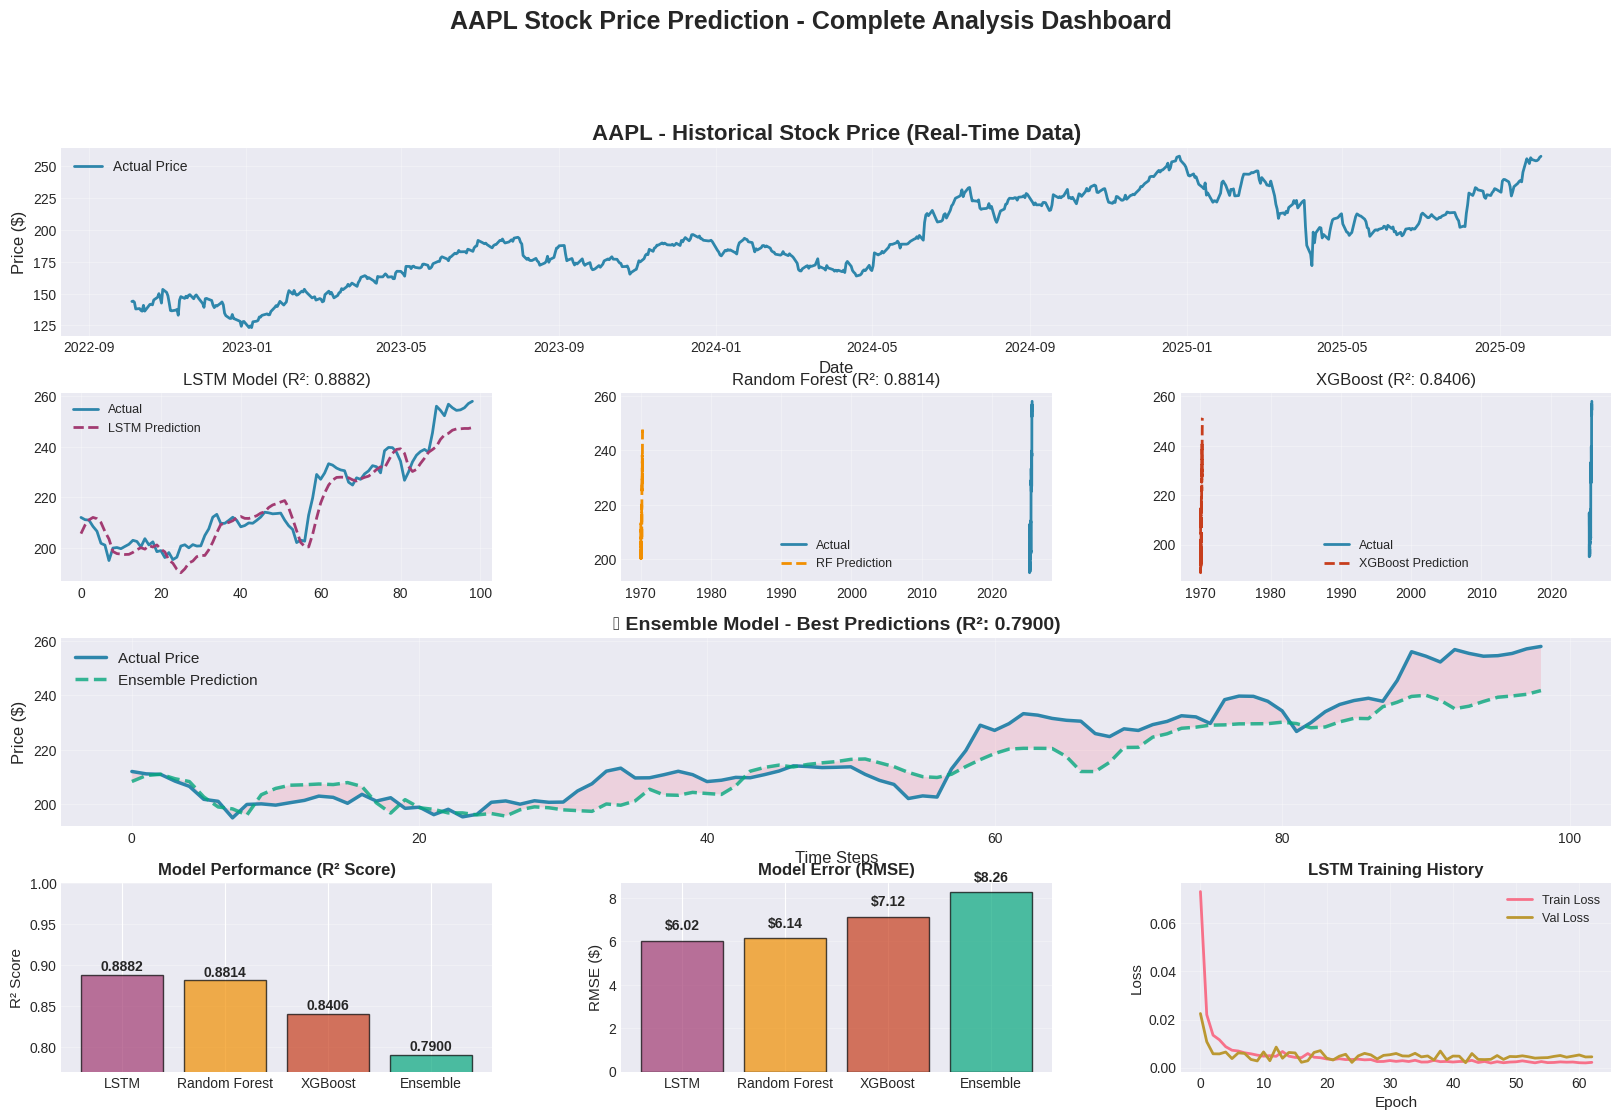

✓ Feature importance saved as 'AAPL_feature_importance.png'


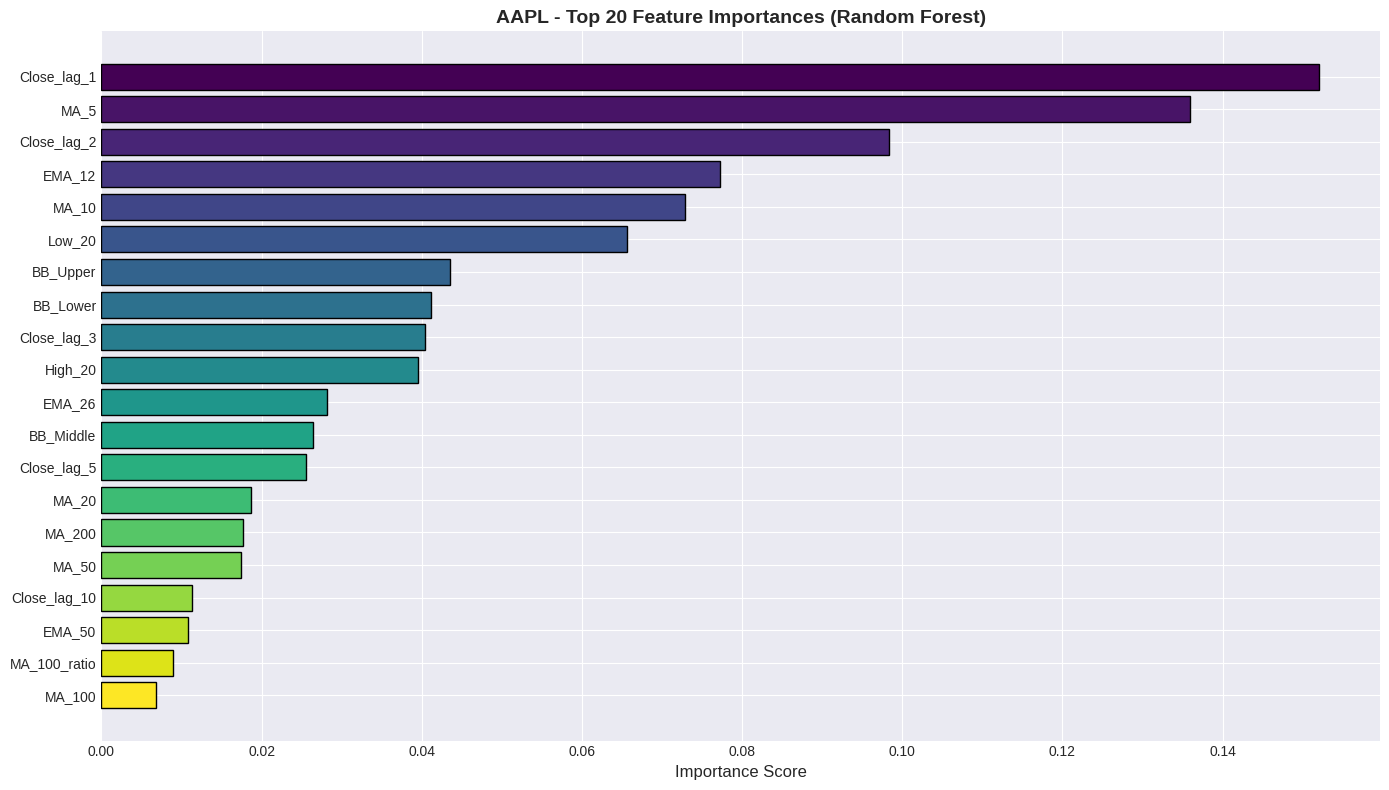


🔮 Predicting next 30 days...
✓ Future prediction saved as 'AAPL_future_prediction.png'


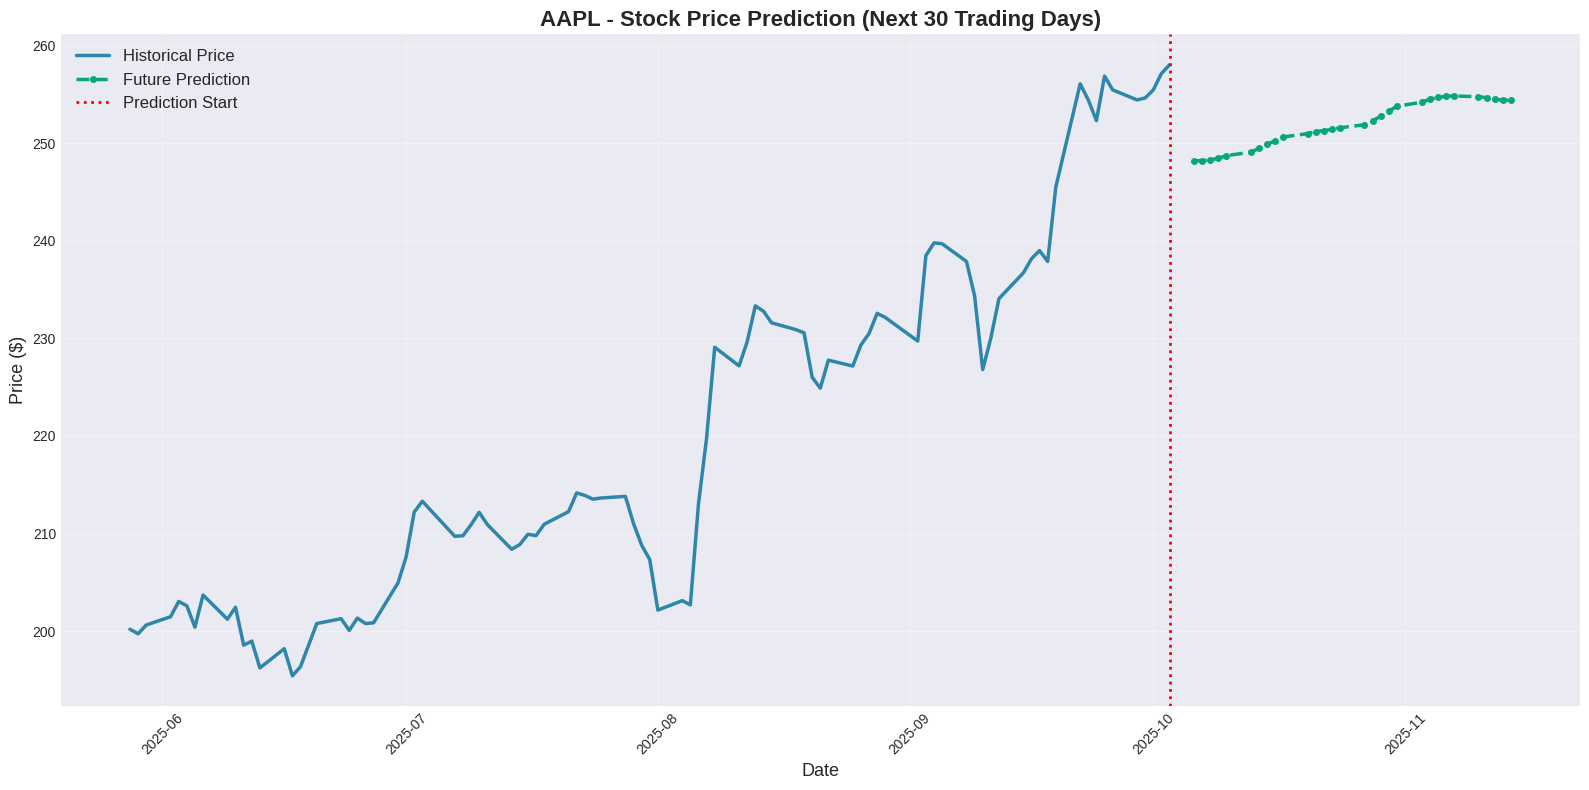


📊 Future Price Predictions:
                     Date  Predicted_Price
2025-10-06 00:00:00-04:00       248.196392
2025-10-07 00:00:00-04:00       248.199118
2025-10-08 00:00:00-04:00       248.279325
2025-10-09 00:00:00-04:00       248.451305
2025-10-10 00:00:00-04:00       248.723083
2025-10-13 00:00:00-04:00       249.068533
2025-10-14 00:00:00-04:00       249.457438
2025-10-15 00:00:00-04:00       249.862253
2025-10-16 00:00:00-04:00       250.248371
2025-10-17 00:00:00-04:00       250.629713
2025-10-20 00:00:00-04:00       250.974426
2025-10-21 00:00:00-04:00       251.191228
2025-10-22 00:00:00-04:00       251.281337
2025-10-23 00:00:00-04:00       251.411452
2025-10-24 00:00:00-04:00       251.579650
2025-10-27 00:00:00-04:00       251.882403
2025-10-28 00:00:00-04:00       252.304492
2025-10-29 00:00:00-04:00       252.746480
2025-10-30 00:00:00-04:00       253.265961
2025-10-31 00:00:00-04:00       253.785054
2025-11-03 00:00:00-05:00       254.186486
2025-11-04 00:00:00-05:00

  • 52-Week High: $258.10
  • 52-Week Low: $172.00

🤖 MODEL PERFORMANCE:

  LSTM:
    RMSE: $6.02 | MAE: $4.75 | R²: 0.8882 | MAPE: 2.14%

  RF:
    RMSE: $6.14 | MAE: $5.19 | R²: 0.8814 | MAPE: 2.37%

  XGB:
    RMSE: $7.12 | MAE: $5.99 | R²: 0.8406 | MAPE: 2.77%

  ENSEMBLE:
    RMSE: $8.26 | MAE: $6.57 | R²: 0.7900 | MAPE: 2.90%

🏆 BEST MODEL: LSTM with R² = 0.8882


💾 Saving models...
  ✓ LSTM model saved
  ✓ Random Forest model saved
  ✓ XGBoost model saved
  ✓ Data scaler saved


In [ ]:
predictor, results = predict_stock('AAPL', period='3y', epochs=100, future_days=30)



Processing AAPL...

📊 Fetching REAL-TIME data for AAPL...

✓ Data fetched successfully!
  Company: Apple Inc.
  Sector: Technology
  Industry: Consumer Electronics
  Date Range: 2023-10-04 to 2025-10-03
  Total Trading Days: 502
  Latest Price: $258.02

🔧 Creating advanced technical indicators...
✓ Created 51 features. Dataset: 303 rows

🚀 TRAINING ALL MODELS

[1/3] Training LSTM Model...



  LSTM Metrics:
    • RMSE: $8.72
    • MAE:  $6.95
    • R²:   0.6684
    • MAPE: 3.07%

[2/3] Training Random Forest Model...

  Random Forest Metrics:
    • RMSE: $6.06
    • MAE:  $4.84
    • R²:   0.8568
    • MAPE: 2.08%

[3/3] Training XGBoost Model...

  XGBoost Metrics:
    • RMSE: $6.27
    • MAE:  $4.94
    • R²:   0.8466
    • MAPE: 2.14%

  Ensemble Metrics:
    • RMSE: $10.98
    • MAE:  $9.32
    • R²:   0.4742
    • MAPE: 3.97%

✅ ALL MODELS TRAINED SUCCESSFULLY!

📈 Creating visualization dashboard...
✓ Dashboard saved as 'AAPL_analysis_dashboard.png'


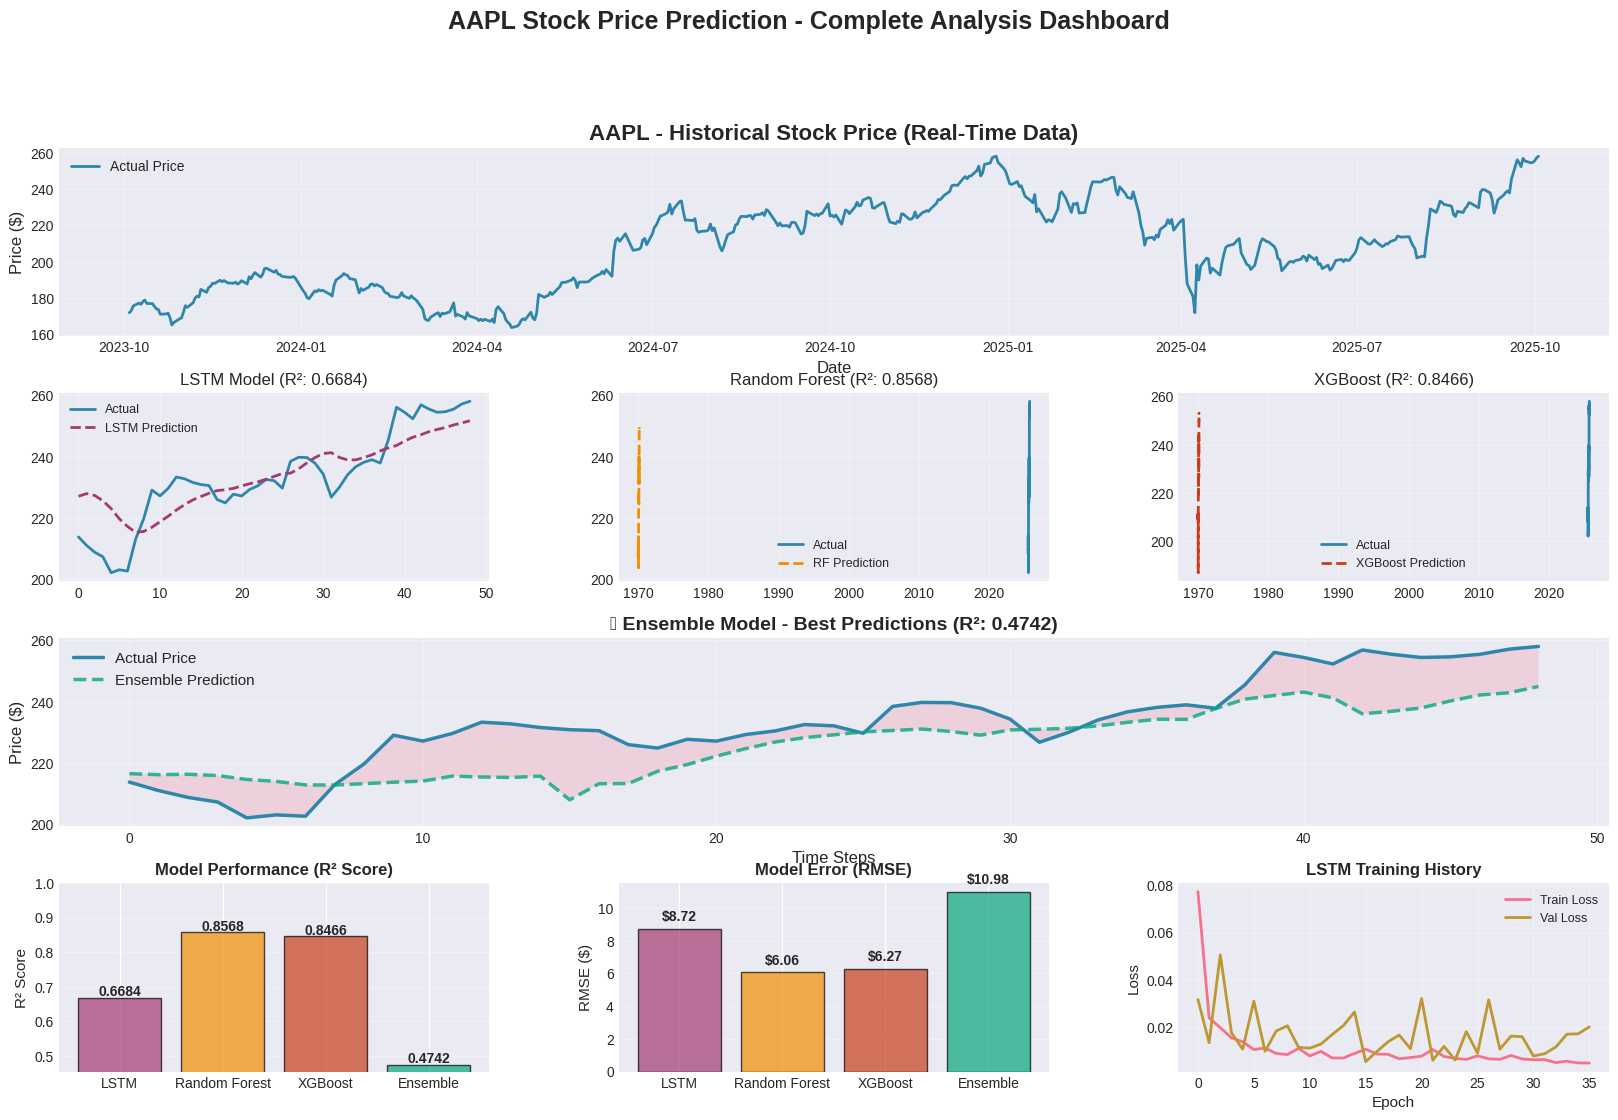

✓ Feature importance saved as 'AAPL_feature_importance.png'


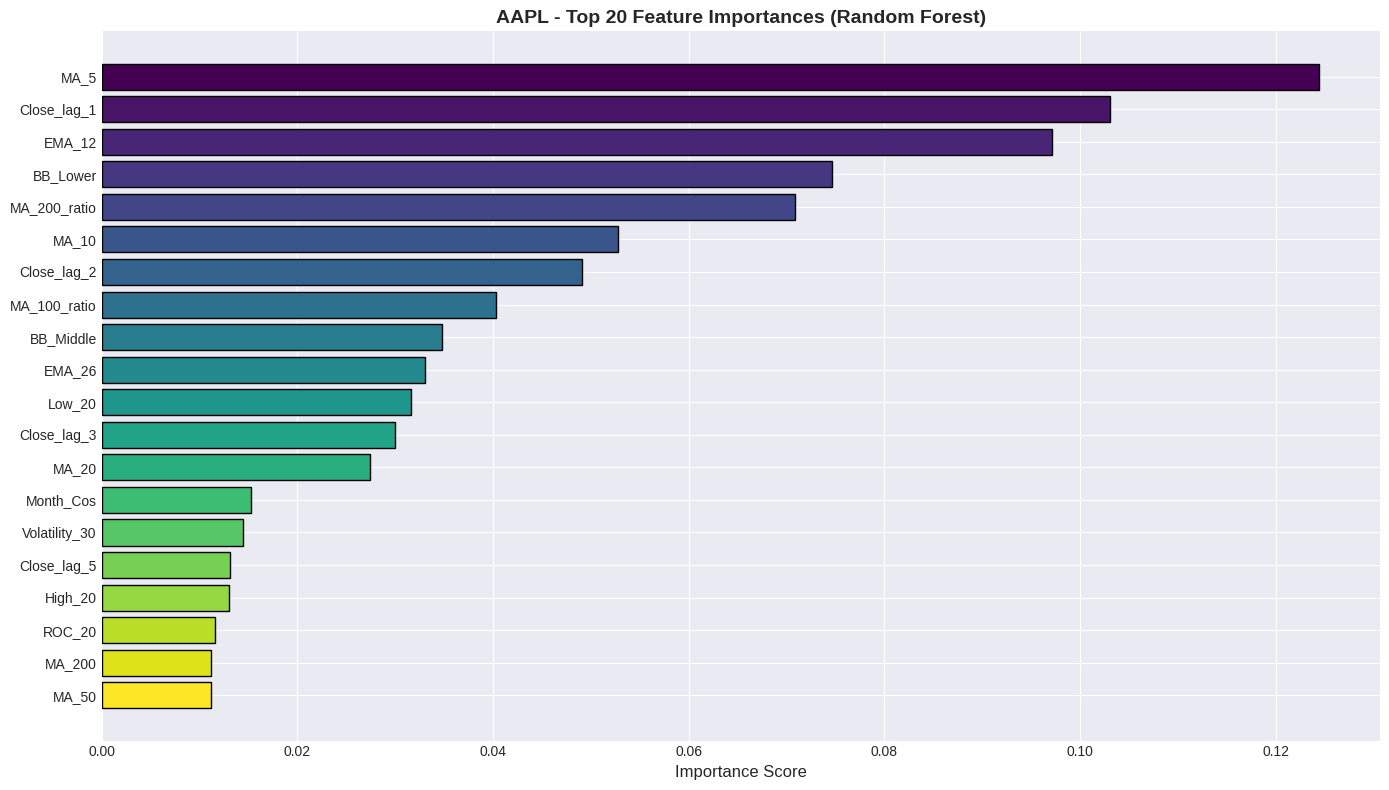


🔮 Predicting next 30 days...
✓ Future prediction saved as 'AAPL_future_prediction.png'


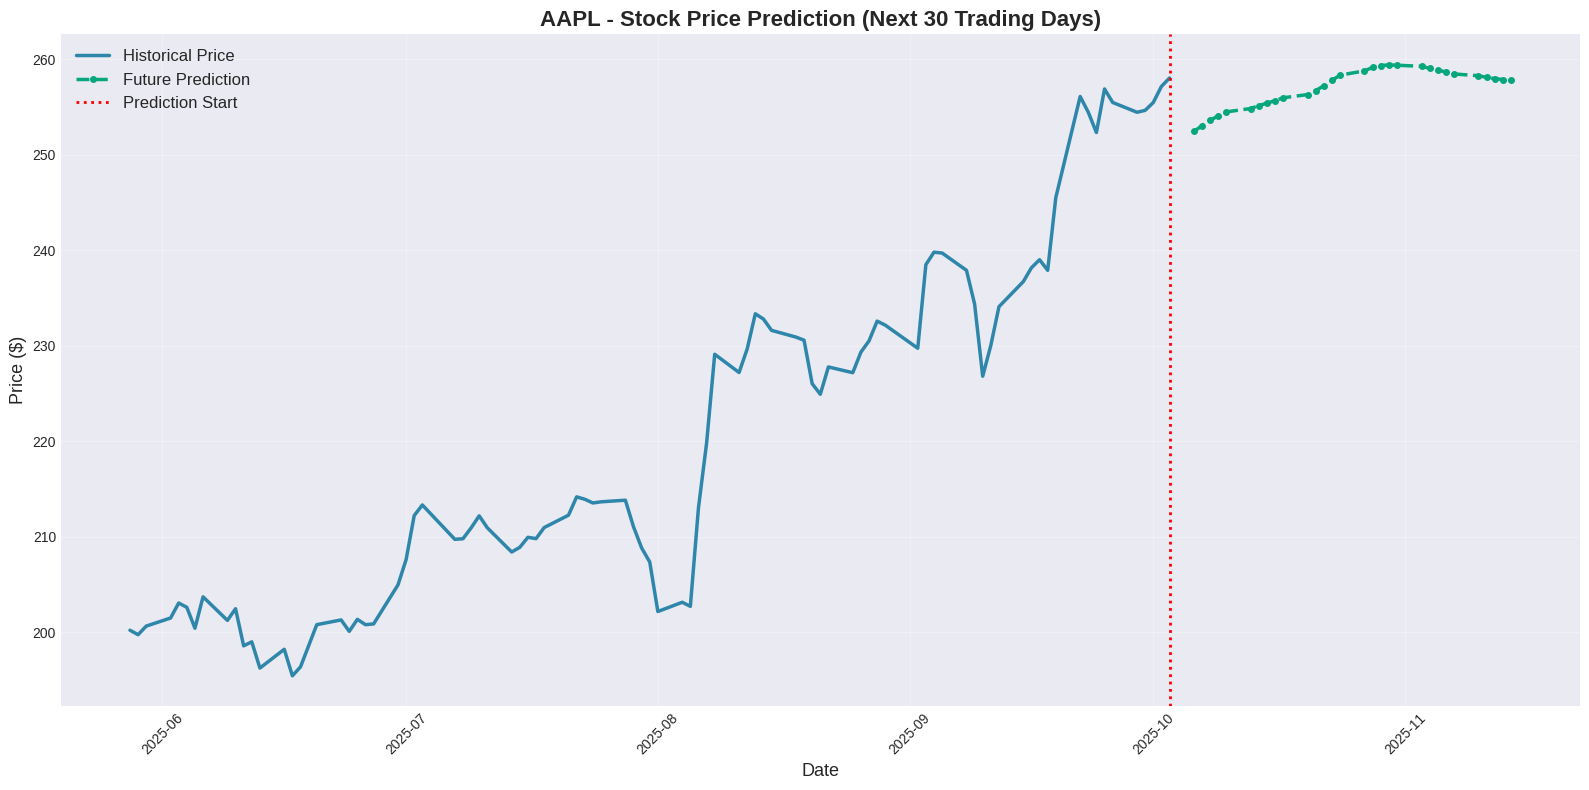


📊 Future Price Predictions:
                     Date  Predicted_Price
2025-10-06 00:00:00-04:00       252.424348
2025-10-07 00:00:00-04:00       253.021187
2025-10-08 00:00:00-04:00       253.577773
2025-10-09 00:00:00-04:00       254.060148
2025-10-10 00:00:00-04:00       254.471692
2025-10-13 00:00:00-04:00       254.823169
2025-10-14 00:00:00-04:00       255.132094
2025-10-15 00:00:00-04:00       255.384872
2025-10-16 00:00:00-04:00       255.655434
2025-10-17 00:00:00-04:00       255.948295
2025-10-20 00:00:00-04:00       256.283723
2025-10-21 00:00:00-04:00       256.698121
2025-10-22 00:00:00-04:00       257.208348
2025-10-23 00:00:00-04:00       257.765827
2025-10-24 00:00:00-04:00       258.319140
2025-10-27 00:00:00-04:00       258.765132
2025-10-28 00:00:00-04:00       259.124543
2025-10-29 00:00:00-04:00       259.318357
2025-10-30 00:00:00-04:00       259.393021
2025-10-31 00:00:00-04:00       259.358481
2025-11-03 00:00:00-05:00       259.238335
2025-11-04 00:00:00-05:00


  LSTM Metrics:
    • RMSE: $29.21
    • MAE:  $22.25
    • R²:   -0.6847
    • MAPE: 9.30%

[2/3] Training Random Forest Model...

  Random Forest Metrics:
    • RMSE: $33.19
    • MAE:  $23.98
    • R²:   -0.8707
    • MAPE: 10.10%

[3/3] Training XGBoost Model...

  XGBoost Metrics:
    • RMSE: $32.56
    • MAE:  $23.41
    • R²:   -0.7997
    • MAPE: 9.87%

  Ensemble Metrics:
    • RMSE: $33.19
    • MAE:  $26.22
    • R²:   -1.1756
    • MAPE: 11.04%

✅ ALL MODELS TRAINED SUCCESSFULLY!

📈 Creating visualization dashboard...
✓ Dashboard saved as 'GOOGL_analysis_dashboard.png'


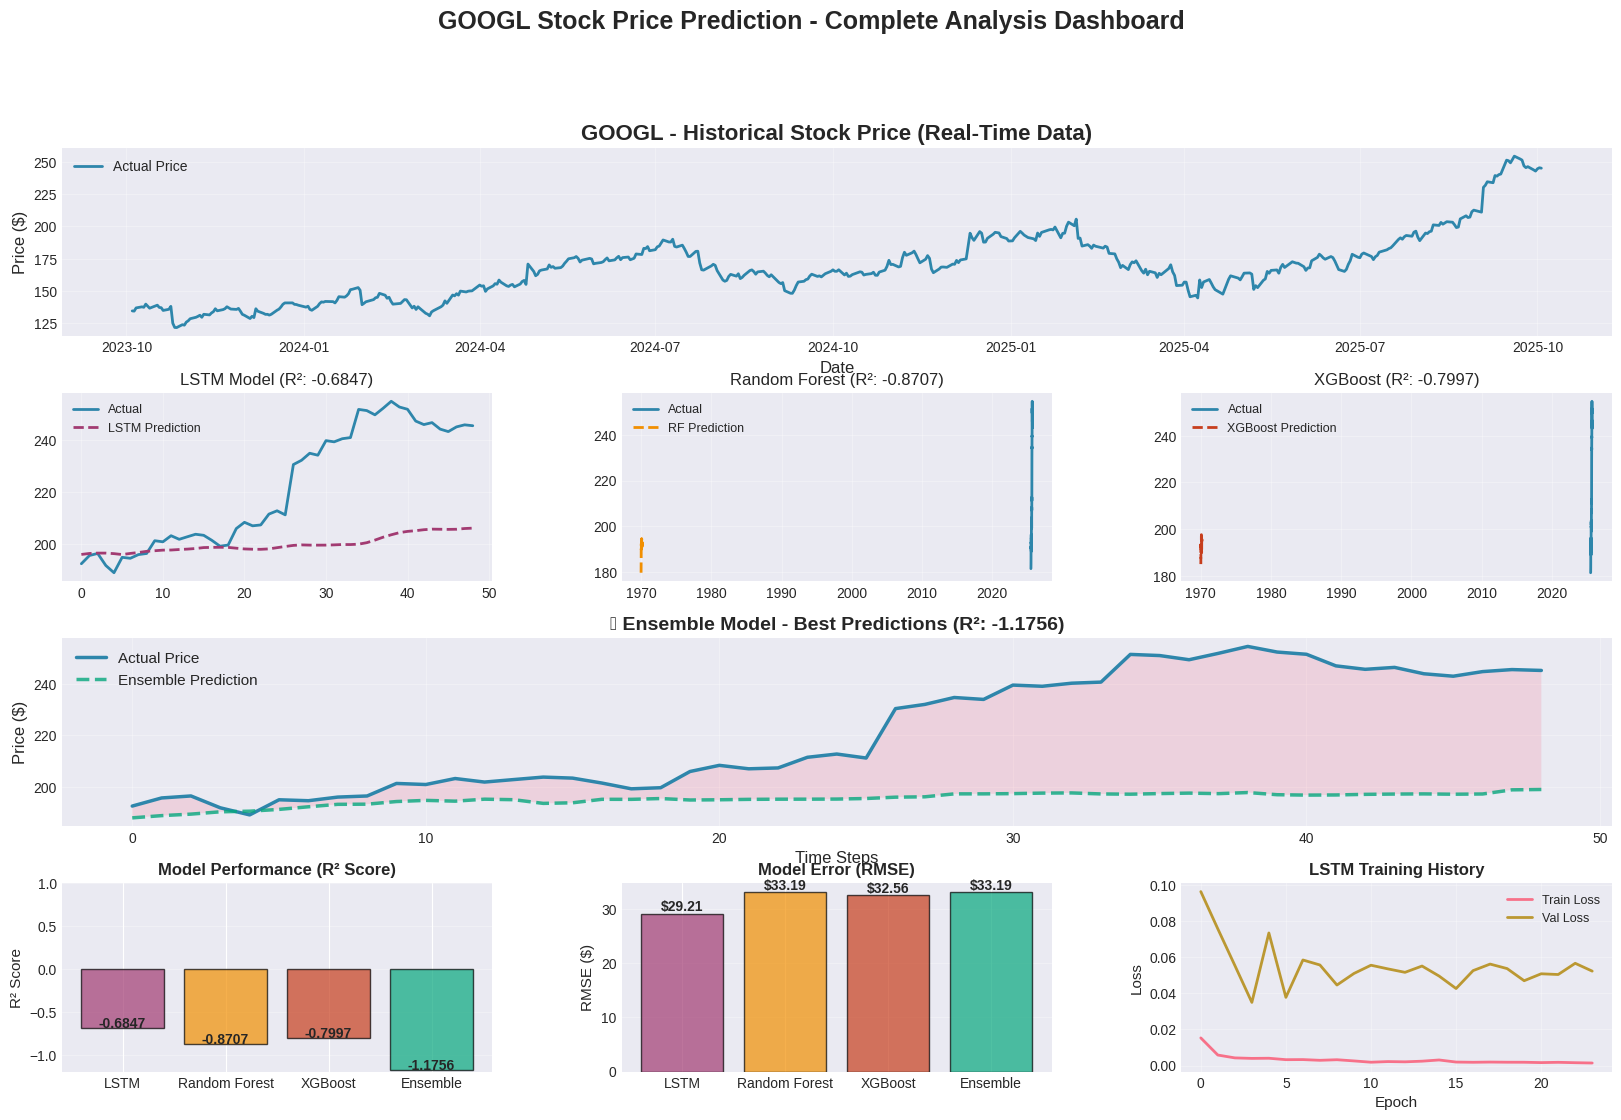

✓ Feature importance saved as 'GOOGL_feature_importance.png'


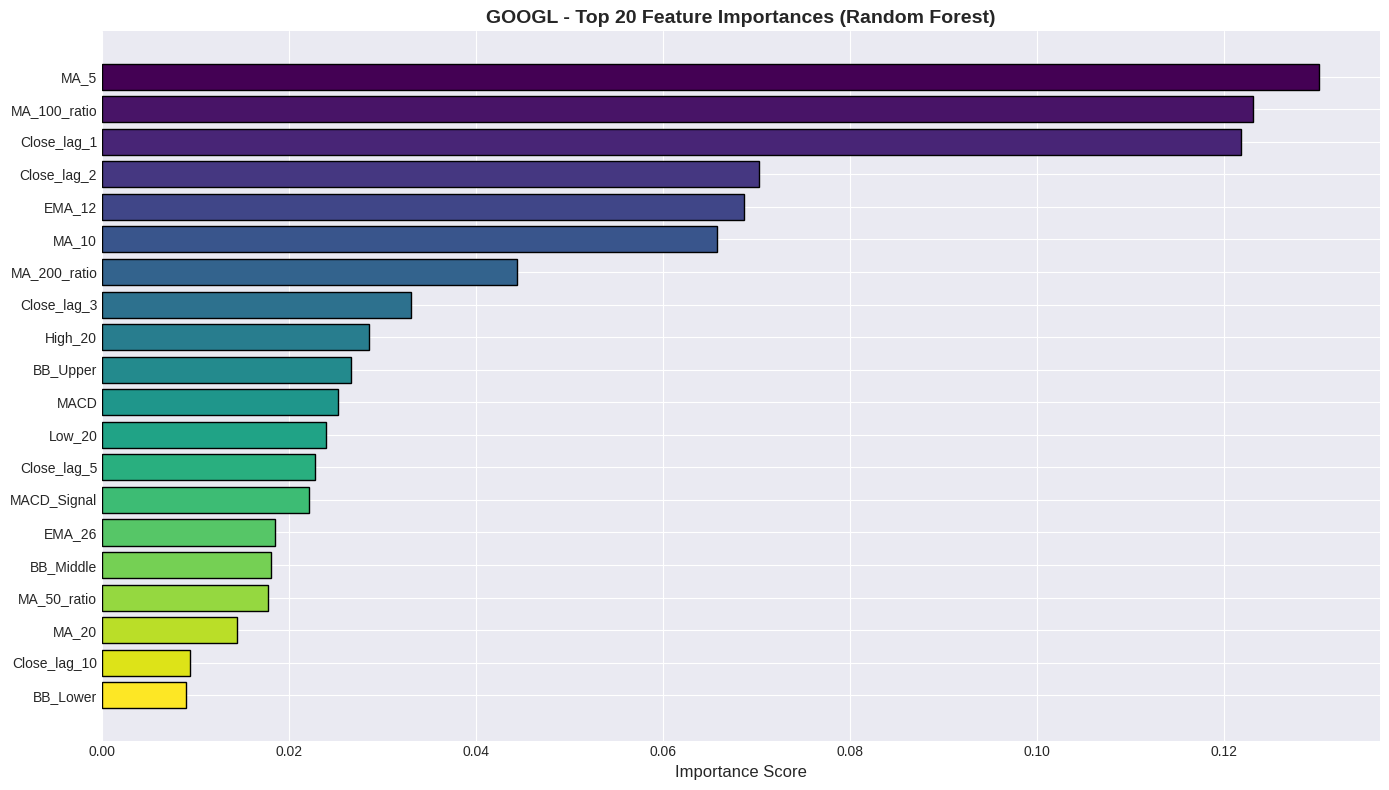


🔮 Predicting next 30 days...
✓ Future prediction saved as 'GOOGL_future_prediction.png'


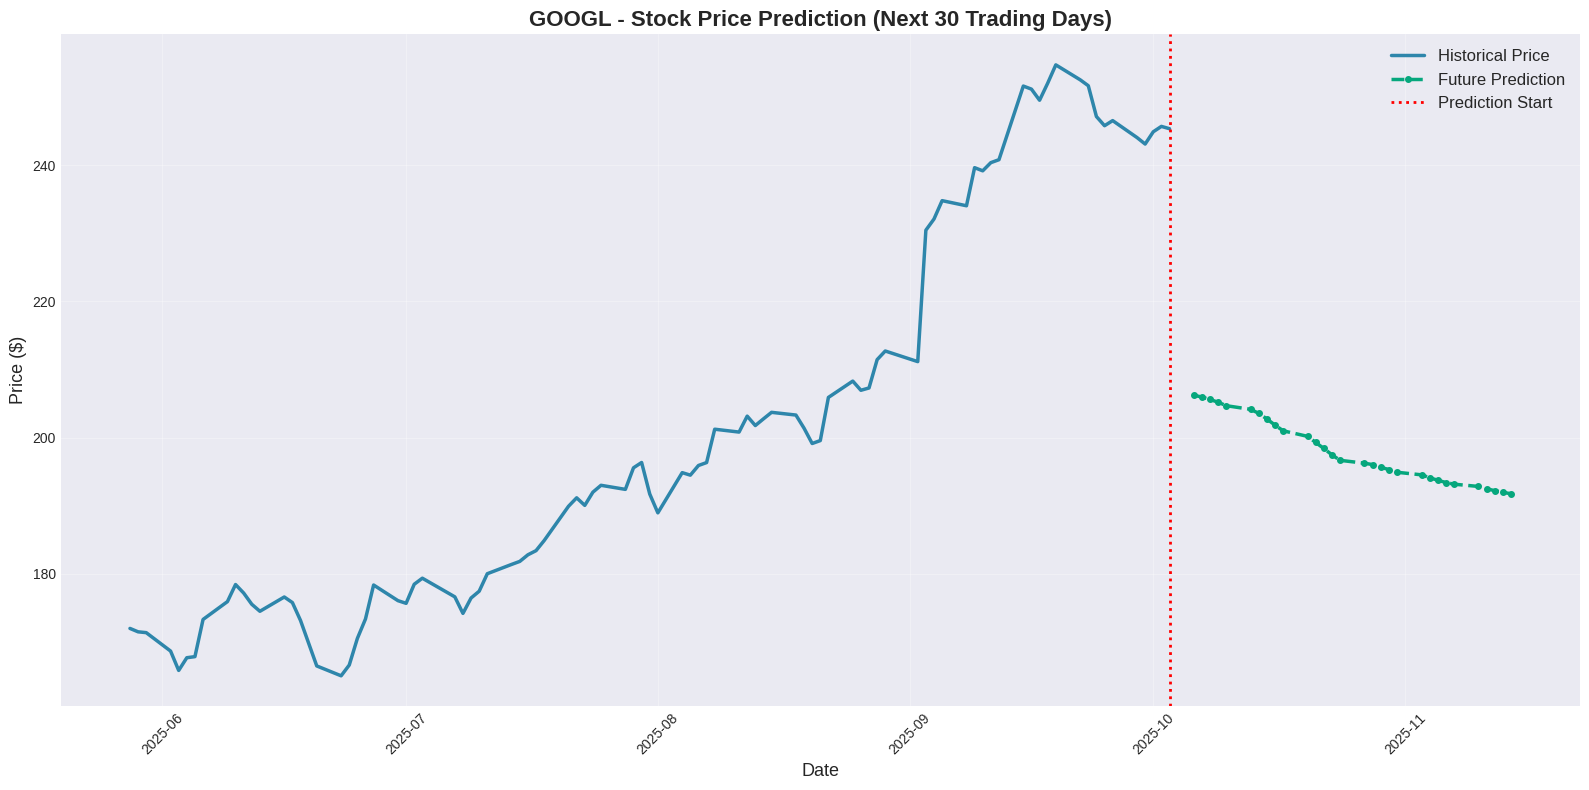


📊 Future Price Predictions:
                     Date  Predicted_Price
2025-10-06 00:00:00-04:00       206.231077
2025-10-07 00:00:00-04:00       205.953998
2025-10-08 00:00:00-04:00       205.602691
2025-10-09 00:00:00-04:00       205.192280
2025-10-10 00:00:00-04:00       204.690091
2025-10-13 00:00:00-04:00       204.154621
2025-10-14 00:00:00-04:00       203.557523
2025-10-15 00:00:00-04:00       202.738115
2025-10-16 00:00:00-04:00       201.828559
2025-10-17 00:00:00-04:00       201.005949
2025-10-20 00:00:00-04:00       200.190882
2025-10-21 00:00:00-04:00       199.294843
2025-10-22 00:00:00-04:00       198.412554
2025-10-23 00:00:00-04:00       197.480512
2025-10-24 00:00:00-04:00       196.673606
2025-10-27 00:00:00-04:00       196.249862
2025-10-28 00:00:00-04:00       196.049418
2025-10-29 00:00:00-04:00       195.656068
2025-10-30 00:00:00-04:00       195.317906
2025-10-31 00:00:00-04:00       194.921456
2025-11-03 00:00:00-05:00       194.542494
2025-11-04 00:00:00-05:00


  LSTM Metrics:
    • RMSE: $50.09
    • MAE:  $49.50
    • R²:   -31.4246
    • MAPE: 9.64%

[2/3] Training Random Forest Model...

  Random Forest Metrics:
    • RMSE: $31.77
    • MAE:  $29.60
    • R²:   -13.4160
    • MAPE: 5.78%

[3/3] Training XGBoost Model...

  XGBoost Metrics:
    • RMSE: $41.26
    • MAE:  $35.99
    • R²:   -23.3079
    • MAPE: 7.03%

  Ensemble Metrics:
    • RMSE: $39.43
    • MAE:  $37.86
    • R²:   -19.0967
    • MAPE: 7.38%

✅ ALL MODELS TRAINED SUCCESSFULLY!

📈 Creating visualization dashboard...
✓ Dashboard saved as 'MSFT_analysis_dashboard.png'


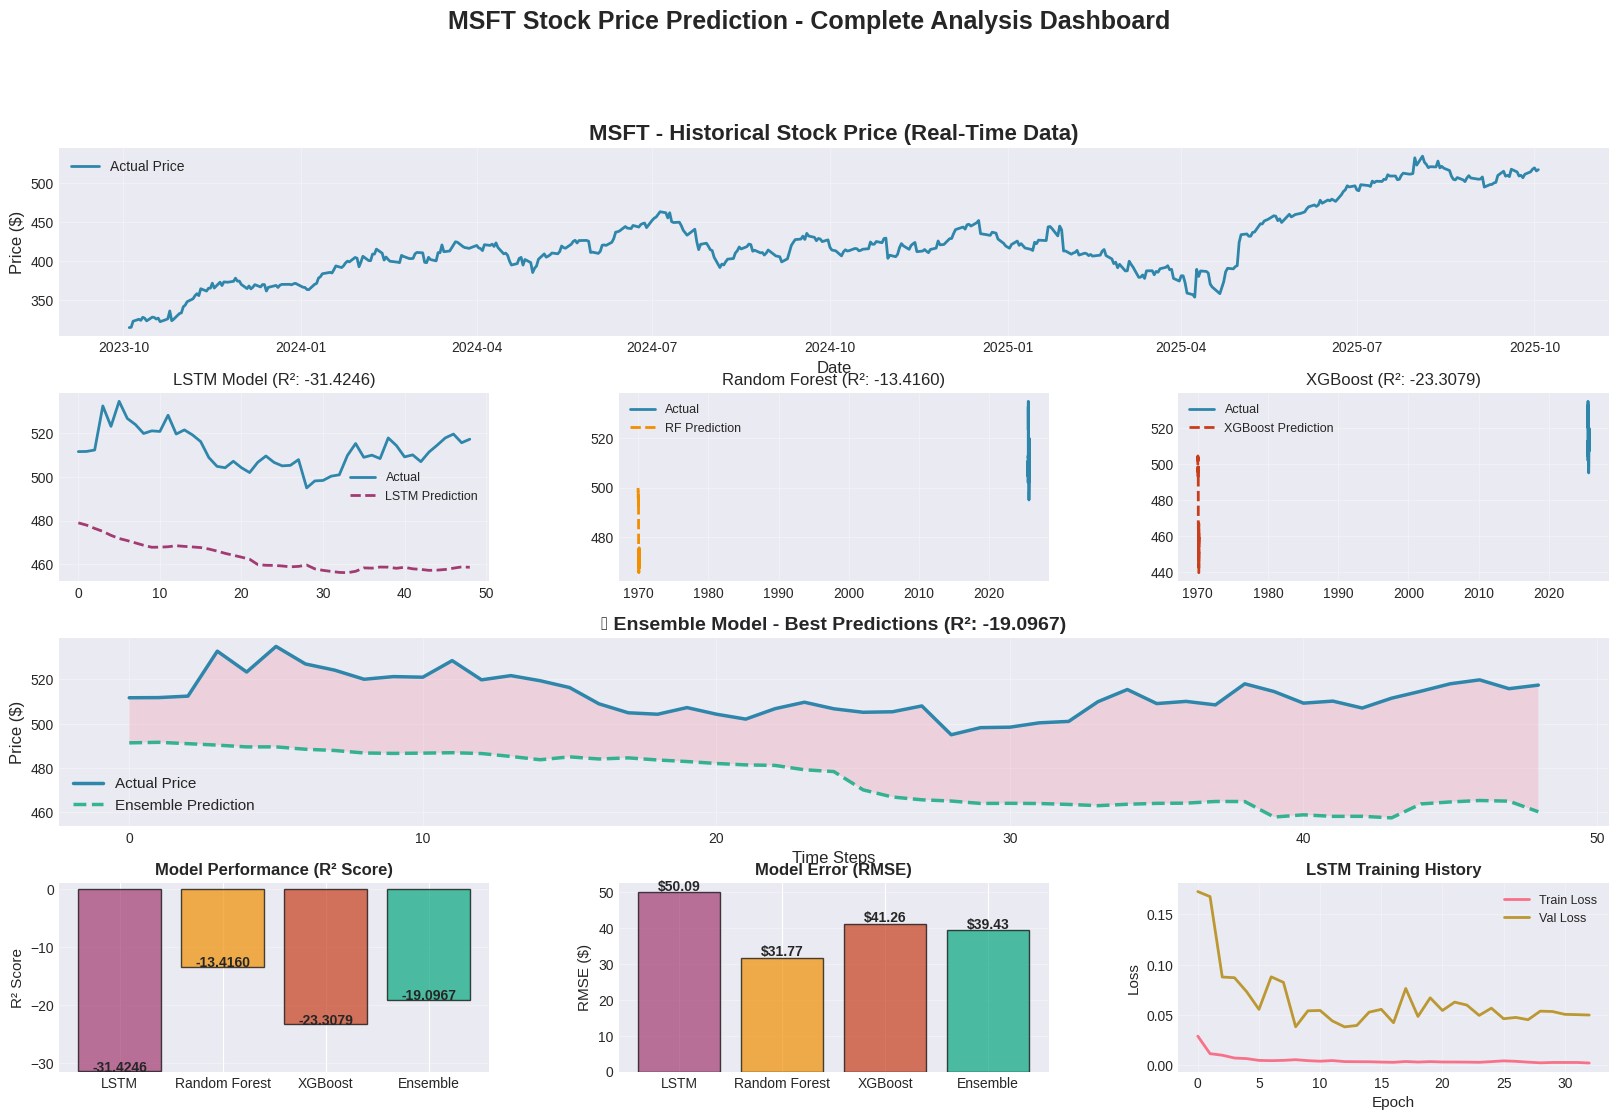

✓ Feature importance saved as 'MSFT_feature_importance.png'


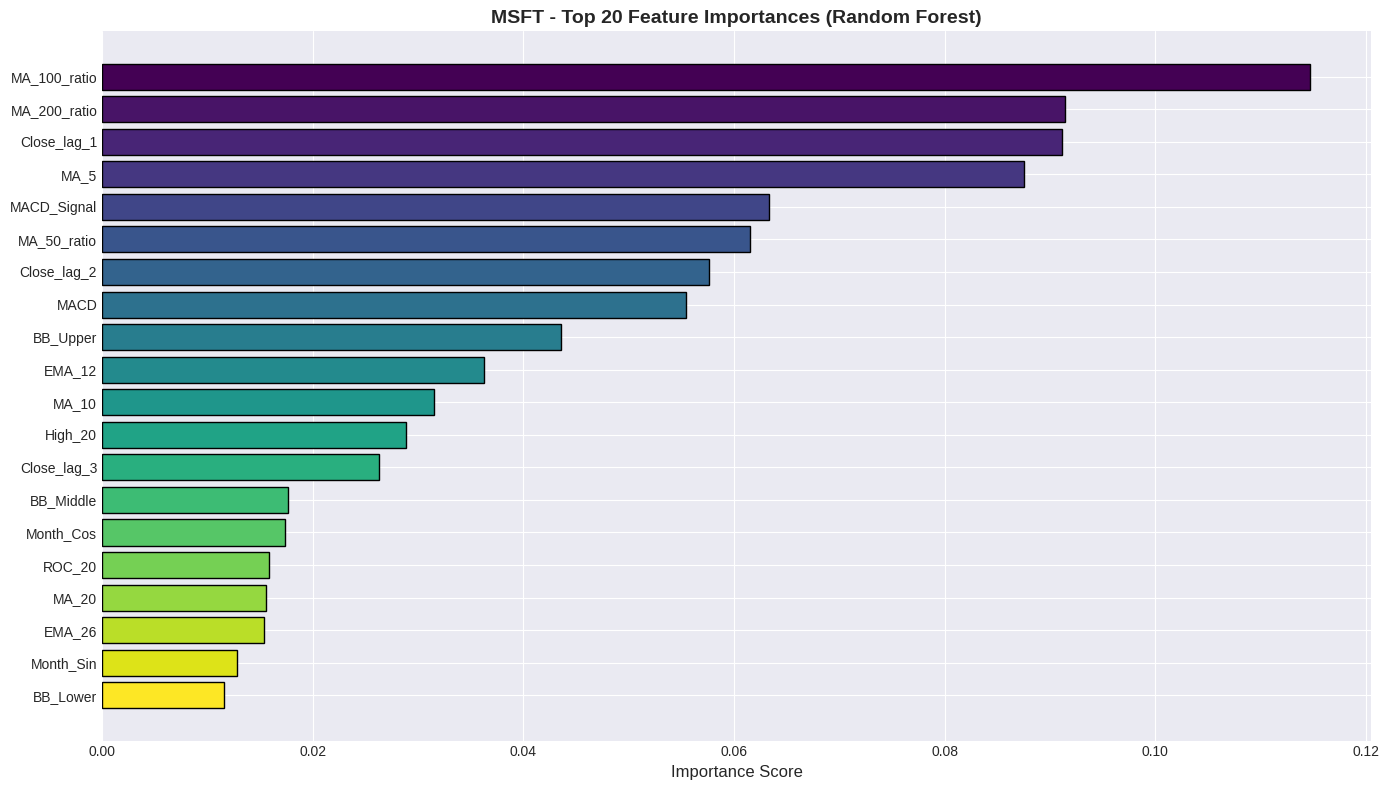


🔮 Predicting next 30 days...
✓ Future prediction saved as 'MSFT_future_prediction.png'


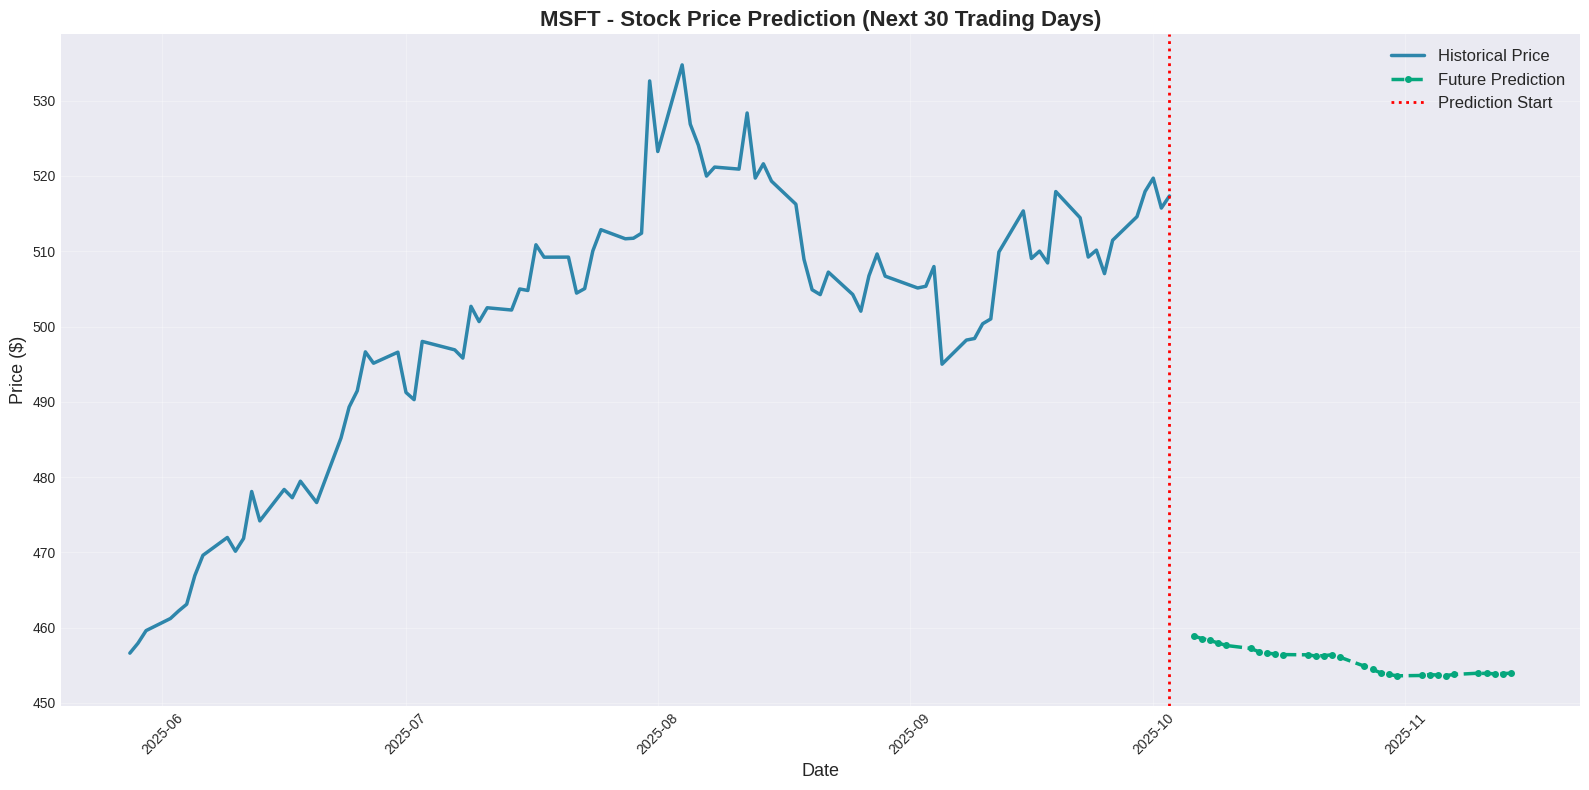


📊 Future Price Predictions:
                     Date  Predicted_Price
2025-10-06 00:00:00-04:00       458.884620
2025-10-07 00:00:00-04:00       458.543076
2025-10-08 00:00:00-04:00       458.289268
2025-10-09 00:00:00-04:00       457.952482
2025-10-10 00:00:00-04:00       457.625235
2025-10-13 00:00:00-04:00       457.237136
2025-10-14 00:00:00-04:00       456.793183
2025-10-15 00:00:00-04:00       456.587746
2025-10-16 00:00:00-04:00       456.519271
2025-10-17 00:00:00-04:00       456.417737
2025-10-20 00:00:00-04:00       456.387089
2025-10-21 00:00:00-04:00       456.228857
2025-10-22 00:00:00-04:00       456.277975
2025-10-23 00:00:00-04:00       456.386149
2025-10-24 00:00:00-04:00       456.065963
2025-10-27 00:00:00-04:00       454.877487
2025-10-28 00:00:00-04:00       454.445169
2025-10-29 00:00:00-04:00       453.993018
2025-10-30 00:00:00-04:00       453.783148
2025-10-31 00:00:00-04:00       453.598020
2025-11-03 00:00:00-05:00       453.641980
2025-11-04 00:00:00-05:00


  LSTM Metrics:
    • RMSE: $39.66
    • MAE:  $29.82
    • R²:   0.3075
    • MAPE: 7.52%

[2/3] Training Random Forest Model...

  Random Forest Metrics:
    • RMSE: $21.04
    • MAE:  $15.12
    • R²:   0.7955
    • MAPE: 3.88%

[3/3] Training XGBoost Model...

  XGBoost Metrics:
    • RMSE: $19.90
    • MAE:  $15.99
    • R²:   0.8170
    • MAPE: 4.41%

  Ensemble Metrics:
    • RMSE: $46.40
    • MAE:  $34.02
    • R²:   0.0521
    • MAPE: 8.54%

✅ ALL MODELS TRAINED SUCCESSFULLY!

📈 Creating visualization dashboard...
✓ Dashboard saved as 'TSLA_analysis_dashboard.png'


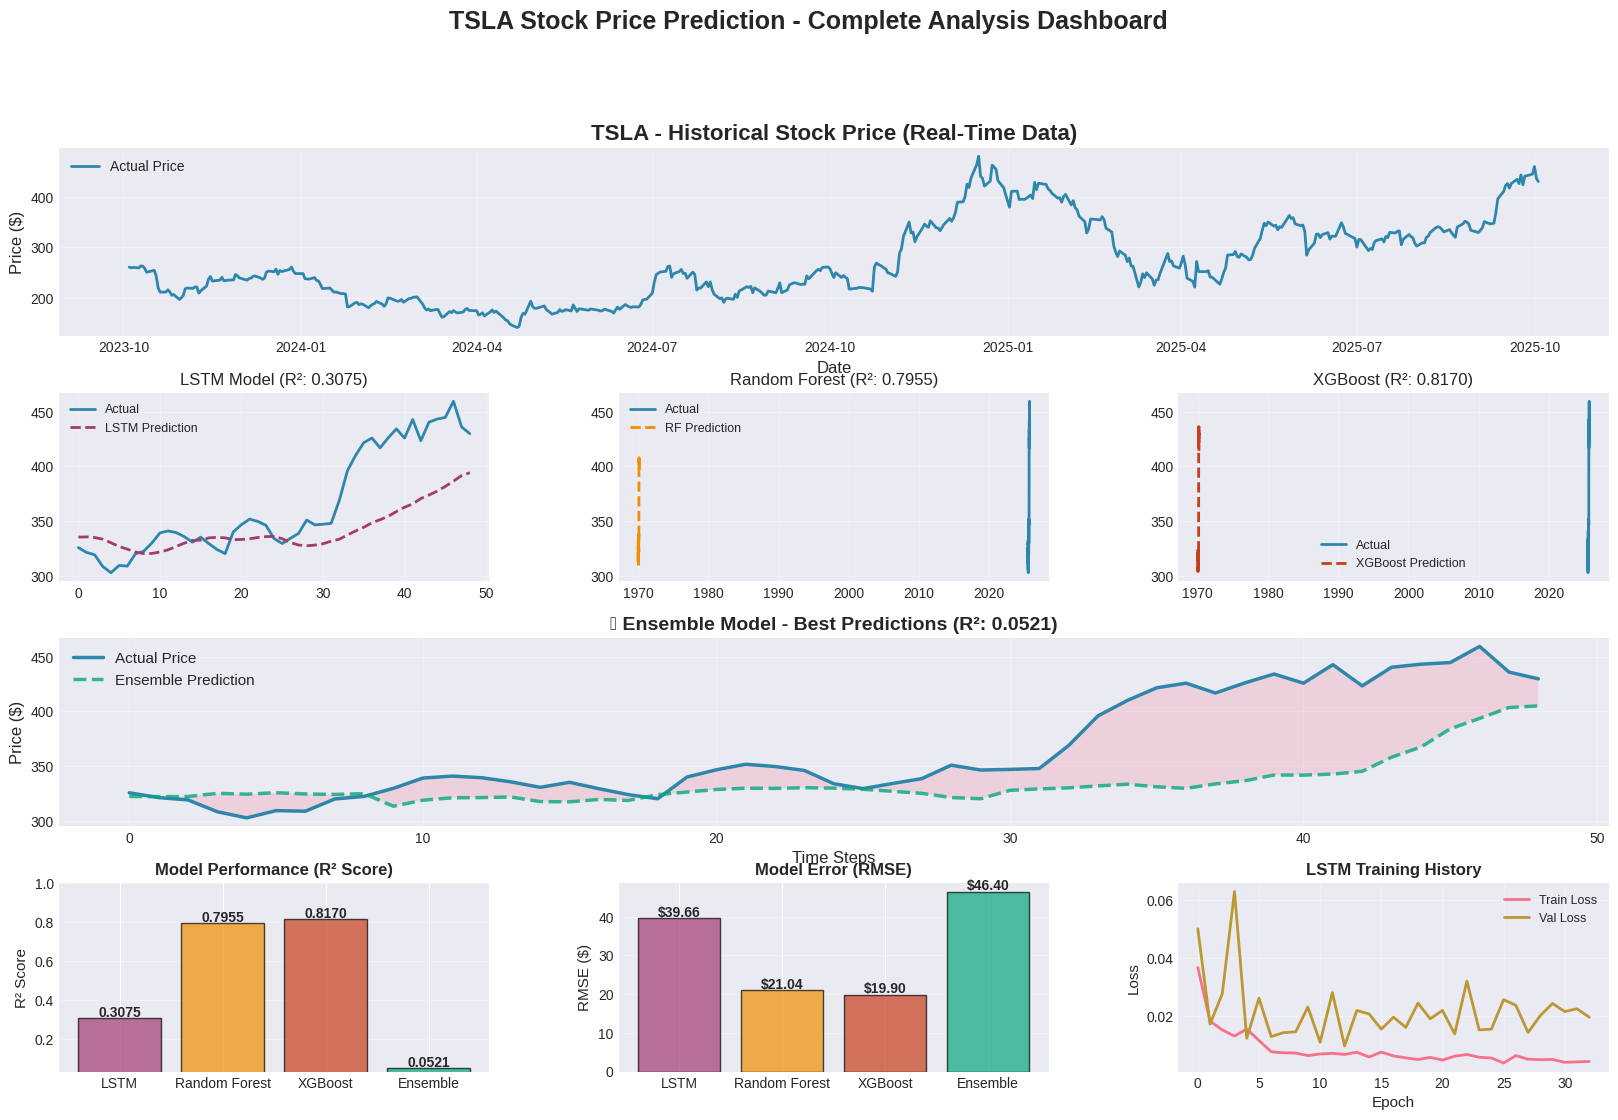

✓ Feature importance saved as 'TSLA_feature_importance.png'


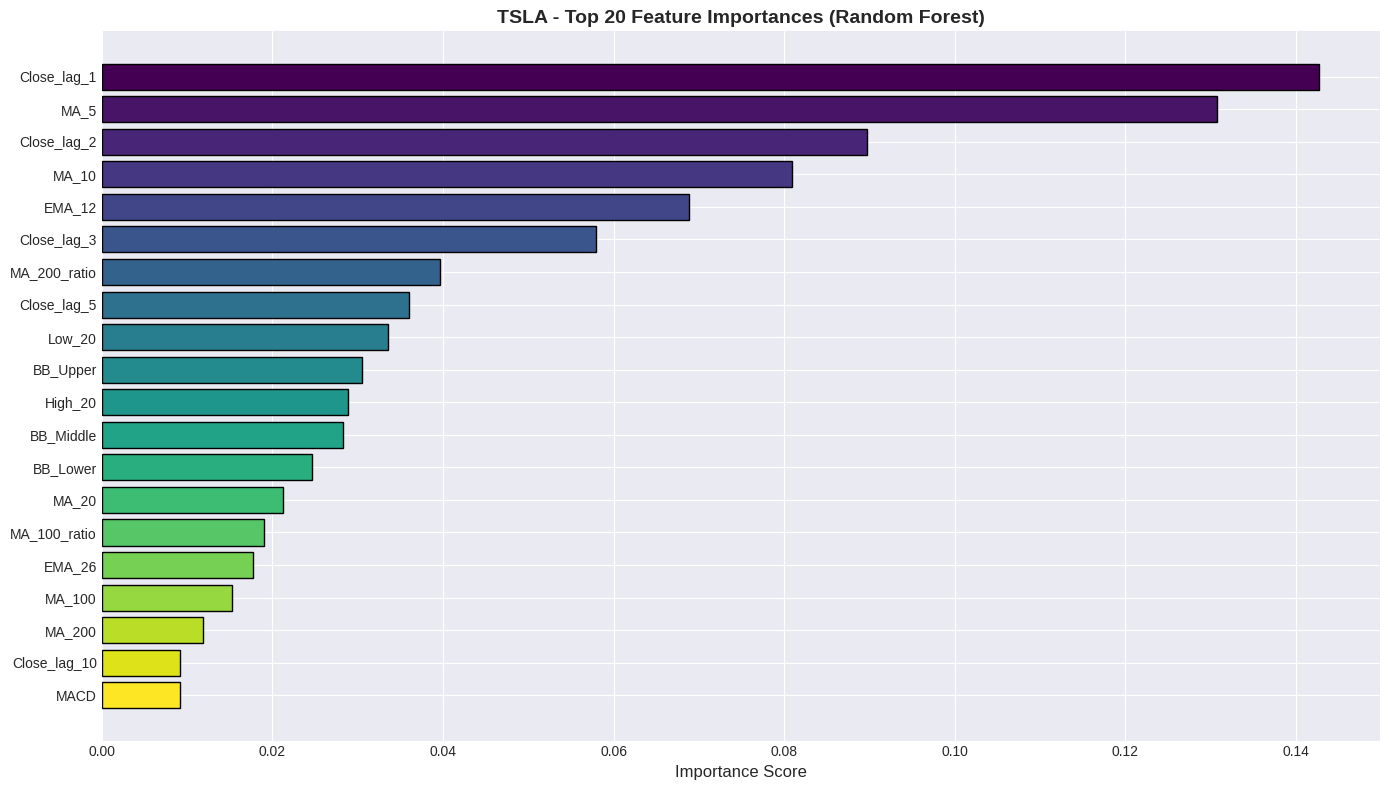


🔮 Predicting next 30 days...
✓ Future prediction saved as 'TSLA_future_prediction.png'


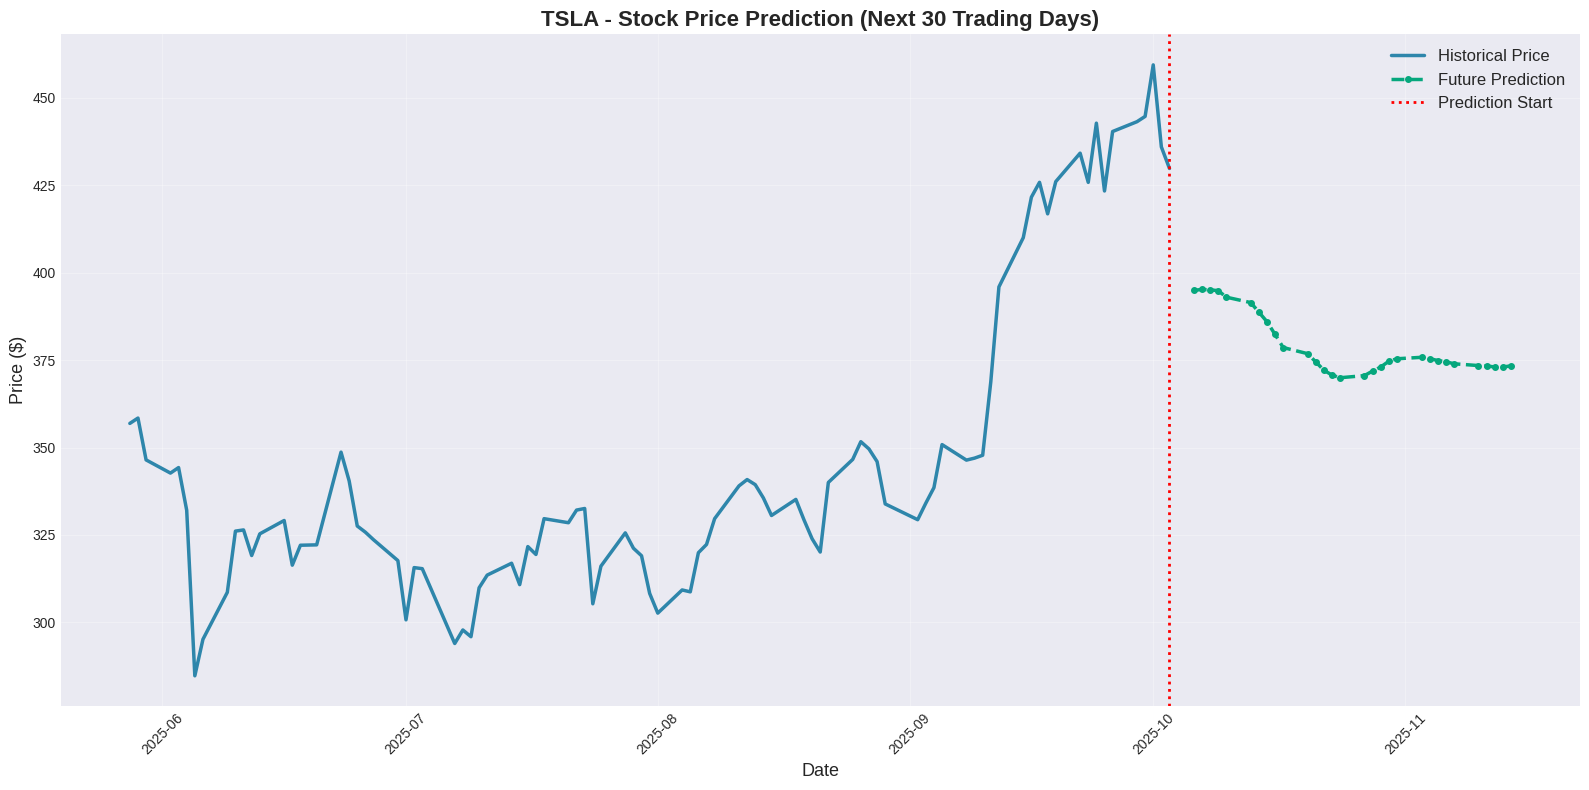


📊 Future Price Predictions:
                     Date  Predicted_Price
2025-10-06 00:00:00-04:00       394.948685
2025-10-07 00:00:00-04:00       395.231114
2025-10-08 00:00:00-04:00       395.098065
2025-10-09 00:00:00-04:00       394.882607
2025-10-10 00:00:00-04:00       393.012394
2025-10-13 00:00:00-04:00       391.466905
2025-10-14 00:00:00-04:00       388.741916
2025-10-15 00:00:00-04:00       386.004581
2025-10-16 00:00:00-04:00       382.354171
2025-10-17 00:00:00-04:00       378.606618
2025-10-20 00:00:00-04:00       376.853810
2025-10-21 00:00:00-04:00       374.523024
2025-10-22 00:00:00-04:00       372.149308
2025-10-23 00:00:00-04:00       370.725072
2025-10-24 00:00:00-04:00       369.963352
2025-10-27 00:00:00-04:00       370.571725
2025-10-28 00:00:00-04:00       371.868836
2025-10-29 00:00:00-04:00       373.017392
2025-10-30 00:00:00-04:00       374.677487
2025-10-31 00:00:00-04:00       375.390336
2025-11-03 00:00:00-05:00       375.810932
2025-11-04 00:00:00-05:00


  LSTM Metrics:
    • RMSE: $6.17
    • MAE:  $4.79
    • R²:   -0.0451
    • MAPE: 2.13%

[2/3] Training Random Forest Model...

  Random Forest Metrics:
    • RMSE: $5.45
    • MAE:  $4.53
    • R²:   0.0640
    • MAPE: 1.99%

[3/3] Training XGBoost Model...

  XGBoost Metrics:
    • RMSE: $6.61
    • MAE:  $5.58
    • R²:   -0.3794
    • MAPE: 2.44%

  Ensemble Metrics:
    • RMSE: $6.84
    • MAE:  $6.06
    • R²:   -0.2833
    • MAPE: 2.67%

✅ ALL MODELS TRAINED SUCCESSFULLY!

📈 Creating visualization dashboard...
✓ Dashboard saved as 'AMZN_analysis_dashboard.png'


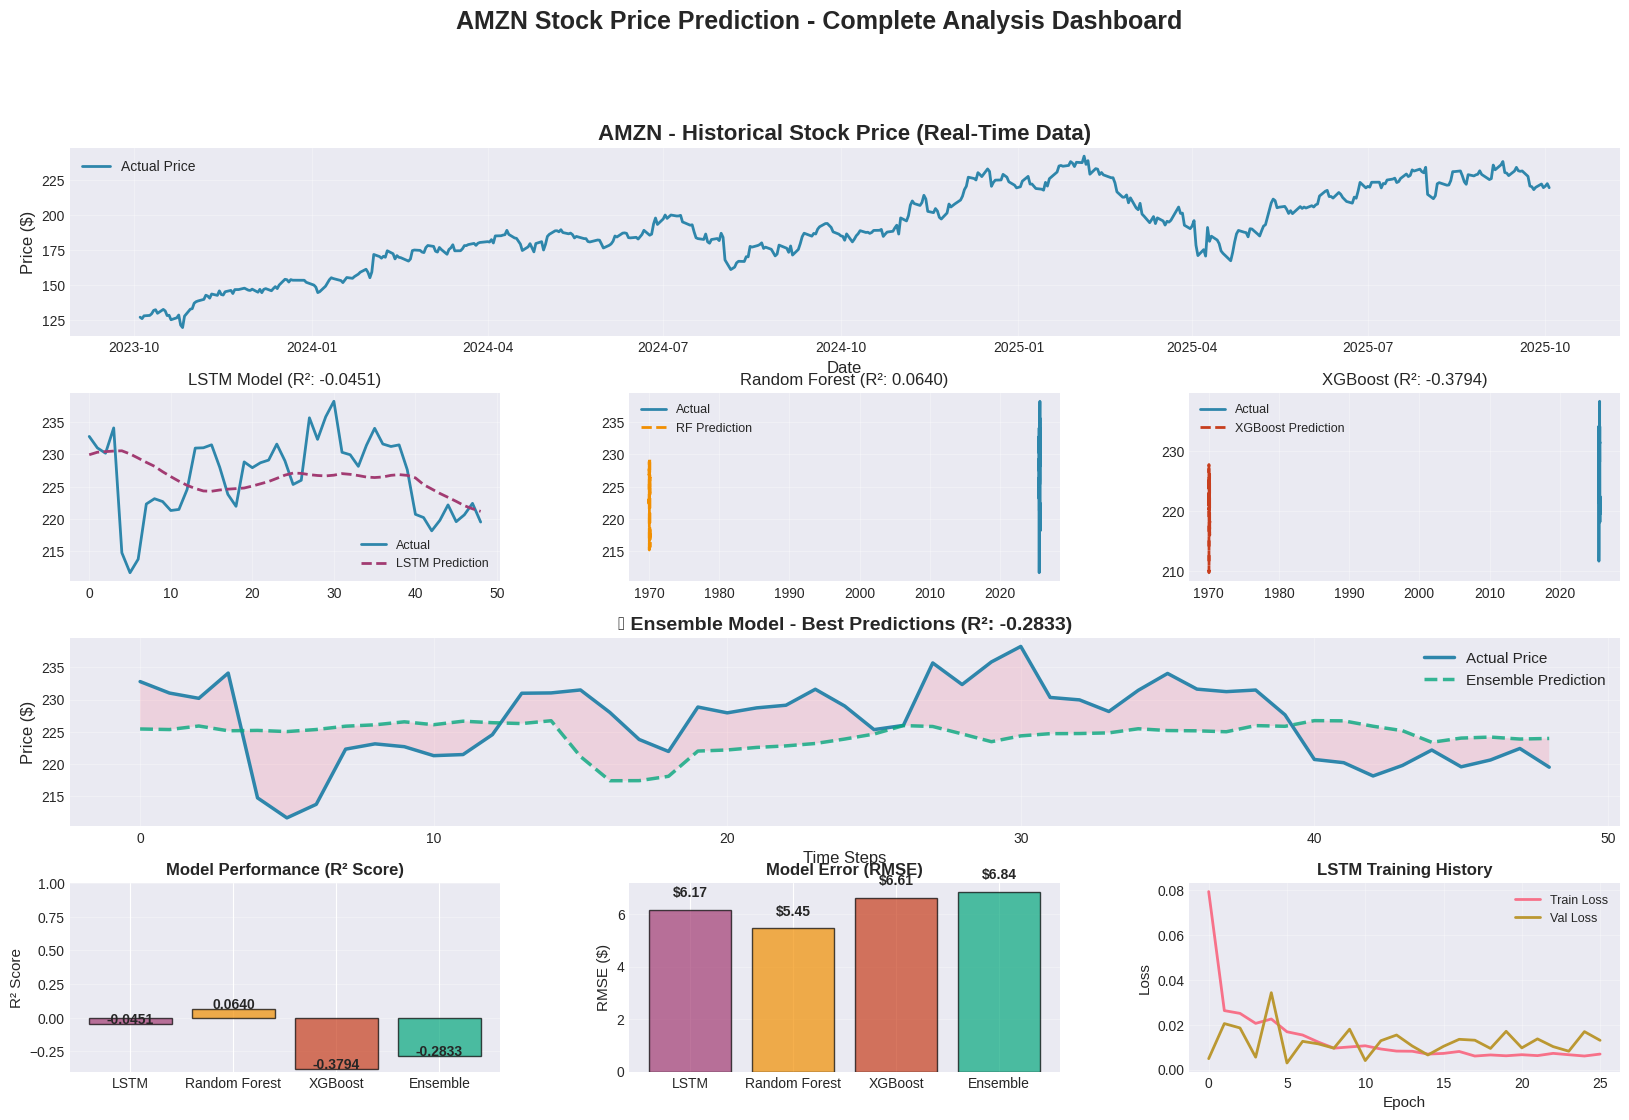

✓ Feature importance saved as 'AMZN_feature_importance.png'


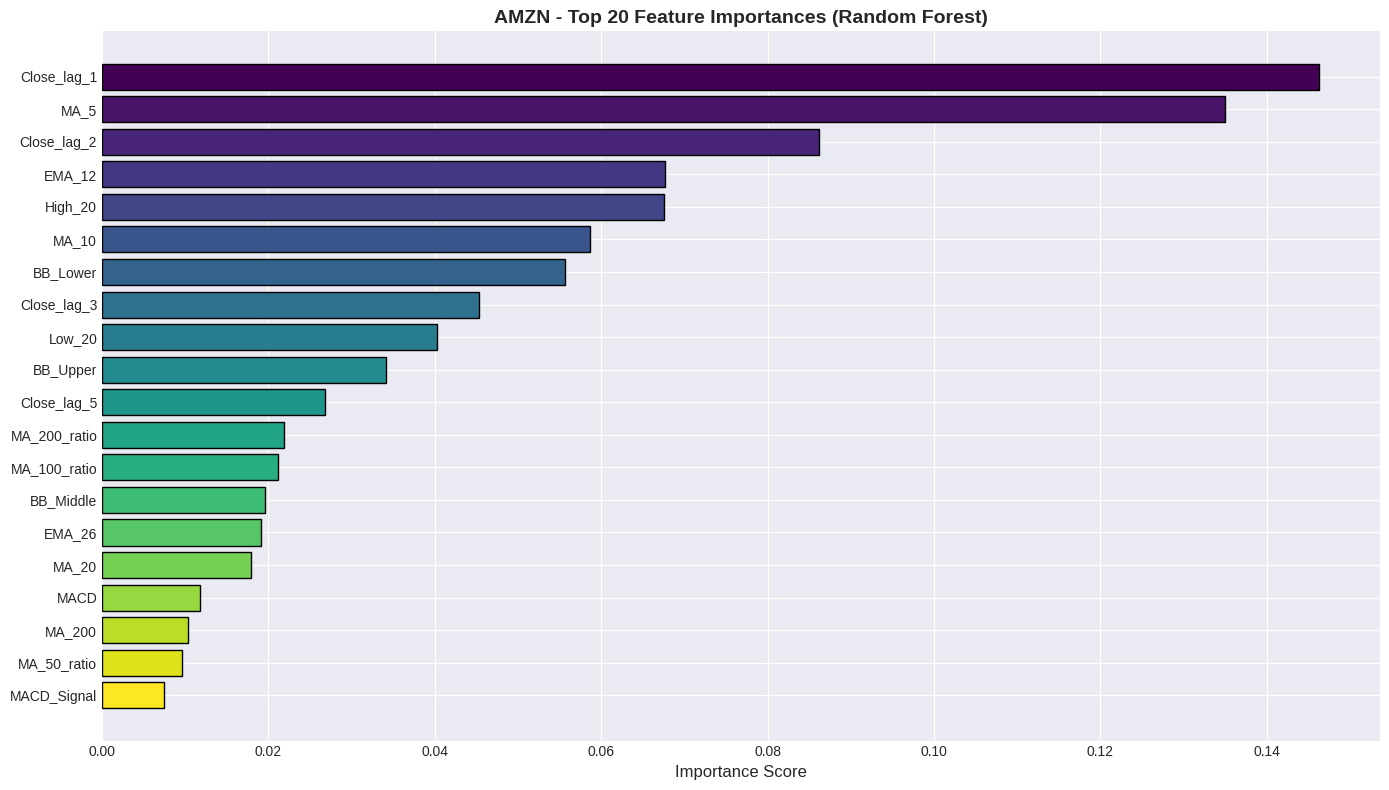


🔮 Predicting next 30 days...
✓ Future prediction saved as 'AMZN_future_prediction.png'


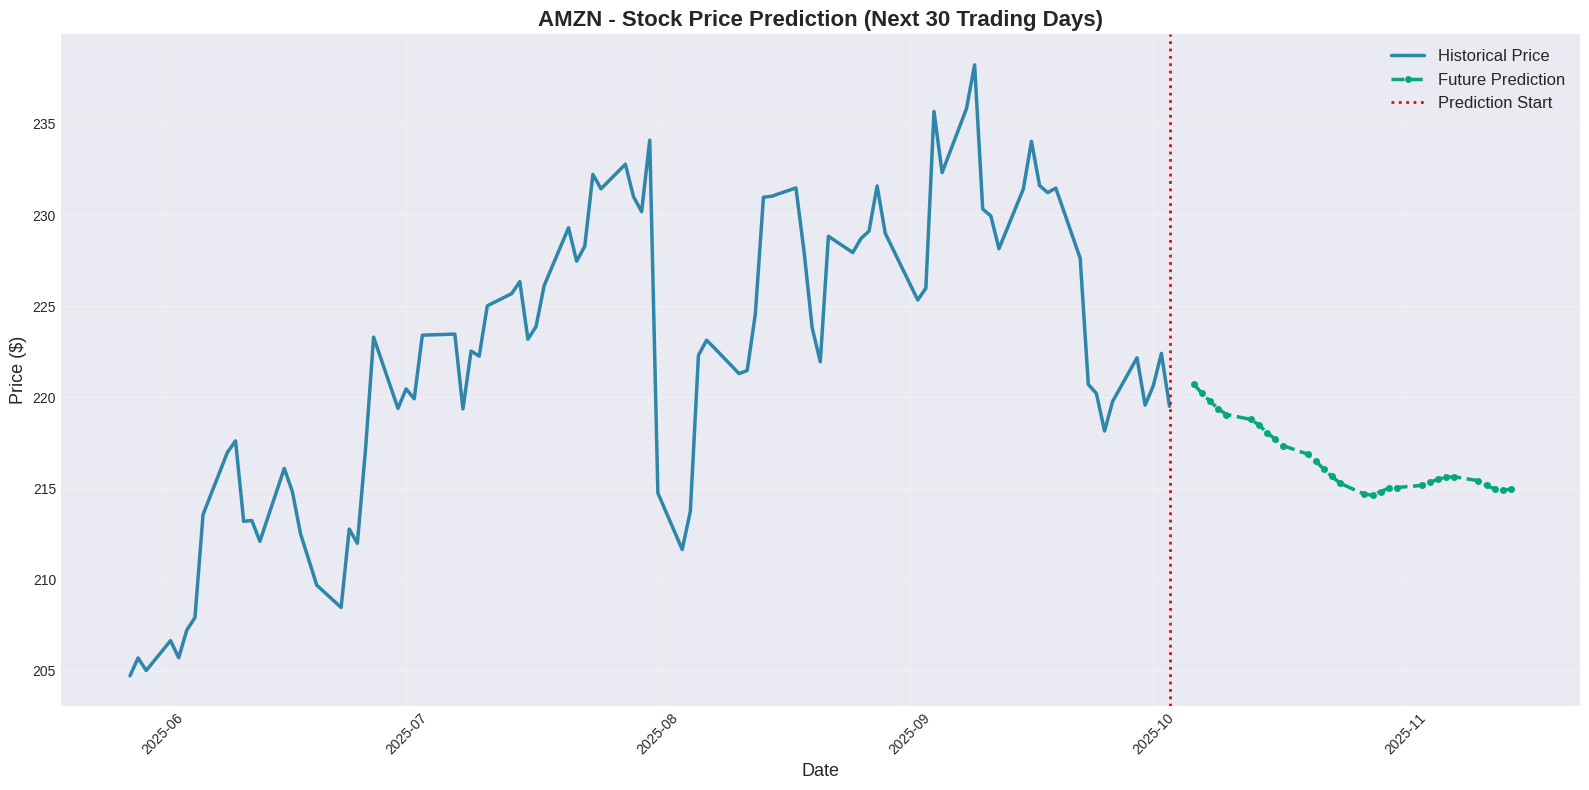


📊 Future Price Predictions:
                     Date  Predicted_Price
2025-10-06 00:00:00-04:00       220.721037
2025-10-07 00:00:00-04:00       220.214173
2025-10-08 00:00:00-04:00       219.785082
2025-10-09 00:00:00-04:00       219.365957
2025-10-10 00:00:00-04:00       219.055394
2025-10-13 00:00:00-04:00       218.789526
2025-10-14 00:00:00-04:00       218.483136
2025-10-15 00:00:00-04:00       218.068251
2025-10-16 00:00:00-04:00       217.702849
2025-10-17 00:00:00-04:00       217.349847
2025-10-20 00:00:00-04:00       216.884316
2025-10-21 00:00:00-04:00       216.503645
2025-10-22 00:00:00-04:00       216.051992
2025-10-23 00:00:00-04:00       215.657554
2025-10-24 00:00:00-04:00       215.284505
2025-10-27 00:00:00-04:00       214.682618
2025-10-28 00:00:00-04:00       214.634706
2025-10-29 00:00:00-04:00       214.828978
2025-10-30 00:00:00-04:00       215.020681
2025-10-31 00:00:00-04:00       215.051962
2025-11-03 00:00:00-05:00       215.167335
2025-11-04 00:00:00-05:00

In [ ]:
stocks = ['AAPL', 'GOOGL', 'MSFT', 'TSLA', 'AMZN']
for stock in stocks:
  print(f"\n\n{'='*70}")
  print(f"Processing {stock}...")
  print(f"{'='*70}")
  predict_stock(stock, period='2y', epochs=50, future_days=30)